# 🔧 Vibration Waveform Analysis — ISO 10816-3
**v6 | Jupyter Edition | ตรวจสอบข้อมูลก่อนวิเคราะห์**

| Session | เนื้อหา |
|---|---|
| 0 | Setup & Imports + Helper Functions |
| 1 | Load Files |
| 2 | Outlier Config |
| 3 | Parse & Clean Data *(กราฟ Outlier Diagnostic ทีละไฟล์)* |
| 3b | Raw Data Plots *(4 subplot ต่อไฟล์)* |
| 3c | **Outlier Removal Audit** *(ตรวจสอบความถูกต้องหลัง Clean)* |
| 4 | **Data Validation** *(flag ไฟล์เสีย / invalid)* |
| 5 | Metric Summary Table |
| 6 | Main Analysis Plots |
| 7 | Diagnostic Summary & Trend |
| 8 | Build DataFrames & Export CSV |


## Session 0 — Setup & Imports

In [1]:
# !pip install scipy matplotlib numpy pandas scikit-learn -q

%matplotlib inline
from IPython.display import display
import re, warnings, os
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew
warnings.filterwarnings('ignore')

# ── Outlier Config defaults (override ได้ใน Session 2) ───────
TRIM_START_MS  = 1.0
IQR_MULTIPLIER = 1.5
REPLACE_METHOD = 'interpolate'

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Import เรียบร้อย")


✅ Import เรียบร้อย


### 0b — Parser

In [2]:
NUM_RE  = re.compile(r'-?(?:\d+\.?\d*|\.\d+)')
SKIP_KW = ('---', 'Time (', 'Amplitude', '***',
           'Equipment', 'Meas.', 'Date/Time', 'Waveform')

def parse_waveform_txt(content_bytes):
    text = content_bytes.decode('utf-8', errors='ignore')
    meta, pairs = {}, []
    for raw in text.splitlines():
        line = raw.rstrip('\r\n'); s = line.strip()
        if 'Equipment:'   in line: meta['equipment']  = line.split('Equipment:')[-1].strip()
        if 'Meas. Point:' in line: meta['meas_point'] = line.split('Meas. Point:')[-1].strip()
        if 'Date/Time:'   in line:
            meta['datetime'] = line.split('Date/Time:')[-1].split('Amplitude:')[0].strip()
        if 'Amplitude:' in line and 'Date/Time:' not in line:
            meta['unit'] = line.split('Amplitude:')[-1].strip()
        if not s or any(k in s for k in SKIP_KW): continue
        toks = NUM_RE.findall(s)
        for i in range(0, len(toks)-1, 2):
            try:
                tv, av = float(toks[i]), float(toks[i+1])
                if tv >= 0: pairs.append((tv, av))
            except ValueError: pass
    if not pairs:
        raise ValueError("ไม่พบข้อมูล numeric")
    pairs.sort(key=lambda x: x[0])
    t = np.array([p[0] for p in pairs])
    a = np.array([p[1] for p in pairs])
    _, idx = np.unique(t, return_index=True)
    return meta, t[idx], a[idx]

print("✅ Parser พร้อม")


✅ Parser พร้อม


### 0c — Signal Processing

In [3]:
ISO_ZONES = {
    'A': {'max': 2.5,  'label': 'Newly Commissioned / Good'},
    'B': {'max': 3.0,  'label': 'Unrestricted Operation'},
    'C': {'max': 4.0,  'label': 'Restricted Operation — Monitor'},
    'D': {'max': 9999, 'label': 'Damage Risk — Act Immediately'},
}

def remove_outliers(time_ms, accel_g, label='',
                    trim_ms=TRIM_START_MS,
                    iqr_k=IQR_MULTIPLIER,
                    method=REPLACE_METHOD):
    t, a = time_ms.copy(), accel_g.copy()
    rpt = {'label': label, 'n_raw': len(a),
           'trim_ms': trim_ms, 'iqr_k': iqr_k, 'method': method,
           'trimmed_count': 0, 'spike_count': 0,
           'spike_max_raw': float(np.max(np.abs(a))),
           'spike_times_ms': [], 'spike_values_g': []}
    if trim_ms > 0:
        keep = t >= trim_ms
        rpt['trimmed_count'] = int(np.sum(~keep))
        t, a = t[keep], a[keep]
        if rpt['trimmed_count']:
            print(f"  [{label}] ✂ Startup trim: {rpt['trimmed_count']} pts")
    q1, q3 = np.percentile(a, 25), np.percentile(a, 75)
    iqr = q3 - q1
    lo, hi = q1 - iqr_k*iqr, q3 + iqr_k*iqr
    rpt.update({'q1':round(float(q1),5), 'q3':round(float(q3),5),
                'iqr':round(float(iqr),5),
                'fence_lo':round(float(lo),5), 'fence_hi':round(float(hi),5)})
    spike_mask = (a < lo) | (a > hi)
    n_sp = int(np.sum(spike_mask))
    rpt['spike_count'] = n_sp
    if n_sp > 0:
        s_idx = np.where(spike_mask)[0]
        rpt['spike_times_ms'] = t[s_idx].tolist()
        rpt['spike_values_g'] = [round(v,4) for v in a[s_idx].tolist()]
        if method == 'interpolate':
            a_c = a.copy().astype(float)
            for idx in s_idx:
                lft = [j for j in range(idx-1,-1,-1) if not spike_mask[j]]
                rgt = [j for j in range(idx+1,len(a)) if not spike_mask[j]]
                if lft and rgt: a_c[idx] = (a[lft[0]]+a[rgt[0]])/2
                elif lft:       a_c[idx] = a[lft[0]]
                elif rgt:       a_c[idx] = a[rgt[0]]
                else:           a_c[idx] = 0.0
            a = a_c
        elif method == 'median':
            a[spike_mask] = float(np.median(a[~spike_mask]))
        else:
            a[spike_mask] = 0.0
        print(f"  [{label}] 🔧 Spikes: {n_sp} pts  fence=[{lo:.3f}, {hi:.3f}]G")
    else:
        print(f"  [{label}] ✅ No spikes  fence=[{lo:.3f}, {hi:.3f}]G")
    rpt.update({'n_clean': len(a),
                'peak_after': round(float(np.max(np.abs(a))),5),
                'rms_after':  round(float(np.sqrt(np.mean(a**2))),5)})
    return t, a, rpt

def compute_metrics(a, t):
    dt = float(np.median(np.diff(t))); fs = 1000./dt
    return {'rms':   float(np.sqrt(np.mean(a**2))),
            'peak':  float(np.max(np.abs(a))),
            'p2p':   float(np.max(a)-np.min(a)),
            'crest': float(np.max(np.abs(a))/np.sqrt(np.mean(a**2))) if np.mean(a**2)>0 else 0,
            'kurt':  float(kurtosis(a)),
            'skew':  float(skew(a)),
            'std':   float(np.std(a)),
            'fs': fs, 'dt': dt, 'n': len(a),
            'dur': float(t[-1]-t[0])}

def iso_zone(cf):
    for z, info in ISO_ZONES.items():
        if cf <= info['max']: return z, info
    return 'D', ISO_ZONES['D']

def compute_fft(a, fs):
    f = rfftfreq(len(a), d=1./fs)
    m = np.abs(rfft(a))*2./len(a)
    return f, m

def top_freqs(freq, mag, n=8, min_hz=5.):
    mask = freq >= min_hz
    ff, mm = freq[mask], mag[mask]
    idx = np.argsort(mm)[-n:][::-1]
    return [(float(ff[i]), float(mm[i])) for i in idx]

def style_ax(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor('#0d1117')
    ax.set_title(title, color='white', fontsize=10, fontweight='bold', pad=7)
    if xlabel: ax.set_xlabel(xlabel, color='#78909c', fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color='#78909c', fontsize=8)
    ax.tick_params(colors='#546e7a', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#1c2a3a')
    ax.grid(True, color='#1c2a3a', lw=0.5, alpha=0.8)

print("✅ Signal processing พร้อม")


✅ Signal processing พร้อม


---
## Session 1 — Load Files

In [4]:
import tkinter as tk
from tkinter import filedialog

print("=" * 62)
print("  📂  เลือกไฟล์ Waveform .txt  (รองรับ 2–5 ไฟล์)")
print("=" * 62)

root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
file_paths = filedialog.askopenfilenames(
    title="เลือกไฟล์ Waveform (.txt)",
    filetypes=[("Text Files", "*.txt"), ("All Files", "*.*")]
)
root.destroy()
file_paths = list(file_paths)
file_names = [os.path.basename(p) for p in file_paths]

if not file_paths:
    raise ValueError("❌ ไม่ได้เลือกไฟล์ กรุณารัน cell นี้ใหม่")

print(f"\n✅ เลือก {len(file_names)} ไฟล์:")
for i, fn in enumerate(file_names):
    print(f"  [{i}] {fn}")


  📂  เลือกไฟล์ Waveform .txt  (รองรับ 2–5 ไฟล์)

✅ เลือก 3 ไฟล์:
  [0] A_Jockey pump_M1A_2925__Jun24.txt
  [1] A_Jockey pump_M1A_2925__Oct24.txt
  [2] A_Jockey pump_M1A_2925__Sep24.txt


---
## Session 2 — Outlier Config
> ⚙️ ปรับค่าตรงนี้ได้ แล้วรัน cell นี้ก่อน Session 3

In [5]:
# ▶▶▶  ปรับค่าตรงนี้ได้  ◀◀◀
TRIM_START_MS  = 1.0           # ตัด startup transient (ms) | 0 = ไม่ตัด
IQR_MULTIPLIER = 1.5           # spike threshold k×IQR      | ลด = ตัดเพิ่ม
REPLACE_METHOD = 'interpolate' # 'interpolate' | 'median' | 'zero'

print("⚙️  Outlier Config:")
print(f"   TRIM_START_MS  = {TRIM_START_MS} ms")
print(f"   IQR_MULTIPLIER = {IQR_MULTIPLIER}")
print(f"   REPLACE_METHOD = '{REPLACE_METHOD}'")


⚙️  Outlier Config:
   TRIM_START_MS  = 1.0 ms
   IQR_MULTIPLIER = 1.5
   REPLACE_METHOD = 'interpolate'


---
## Session 3 — Parse & Clean Data
> 📊 กราฟ Outlier Diagnostic แสดง **ทีละไฟล์** ทันทีหลัง clean

  🔍  Loading & Cleaning

──────────────────────────────────────────────────────────
  ── Jun-24  (A_Jockey pump_M1A_2925__Jun24.txt)
  RAW   N=2047  RMS=0.6183G  Peak=9.1000G  CF=14.717  Kurt=21.606
  [Jun-24] ✂ Startup trim: 3 pts
  [Jun-24] 🔧 Spikes: 1 pts  fence=[-1.786, 1.823]G
  CLEAN N=2044  RMS=0.5847G  Peak=1.4970G  CF=2.560  Kurt=-0.842  Zone B


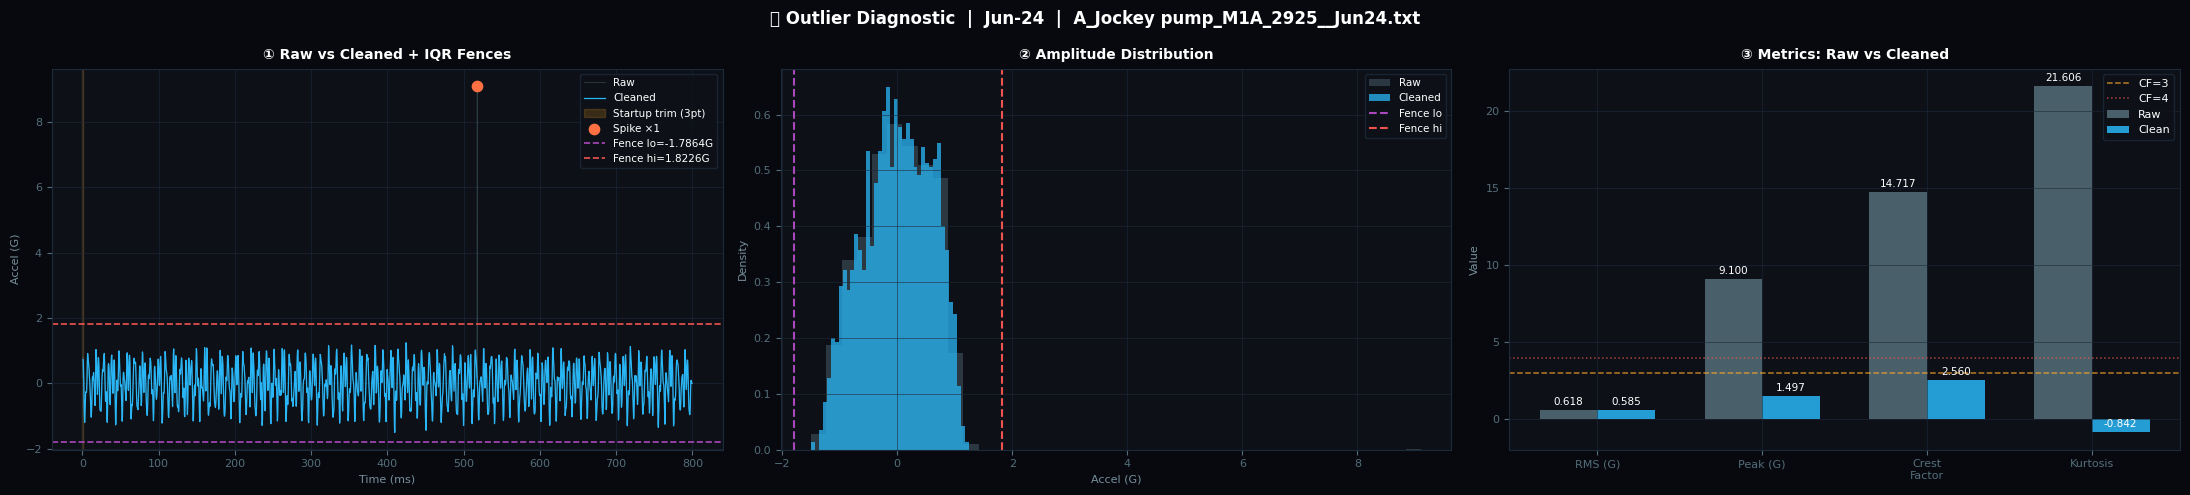

  💾 output\outlier_diag_Jun_24.png


──────────────────────────────────────────────────────────
  ── Oct-24  (A_Jockey pump_M1A_2925__Oct24.txt)
  RAW   N=2048  RMS=0.4834G  Peak=1.6990G  CF=3.515  Kurt=0.078
  [Oct-24] ✂ Startup trim: 3 pts
  [Oct-24] 🔧 Spikes: 27 pts  fence=[-1.232, 1.164]G
  CLEAN N=2045  RMS=0.4648G  Peak=1.2240G  CF=2.633  Kurt=-0.262  Zone B


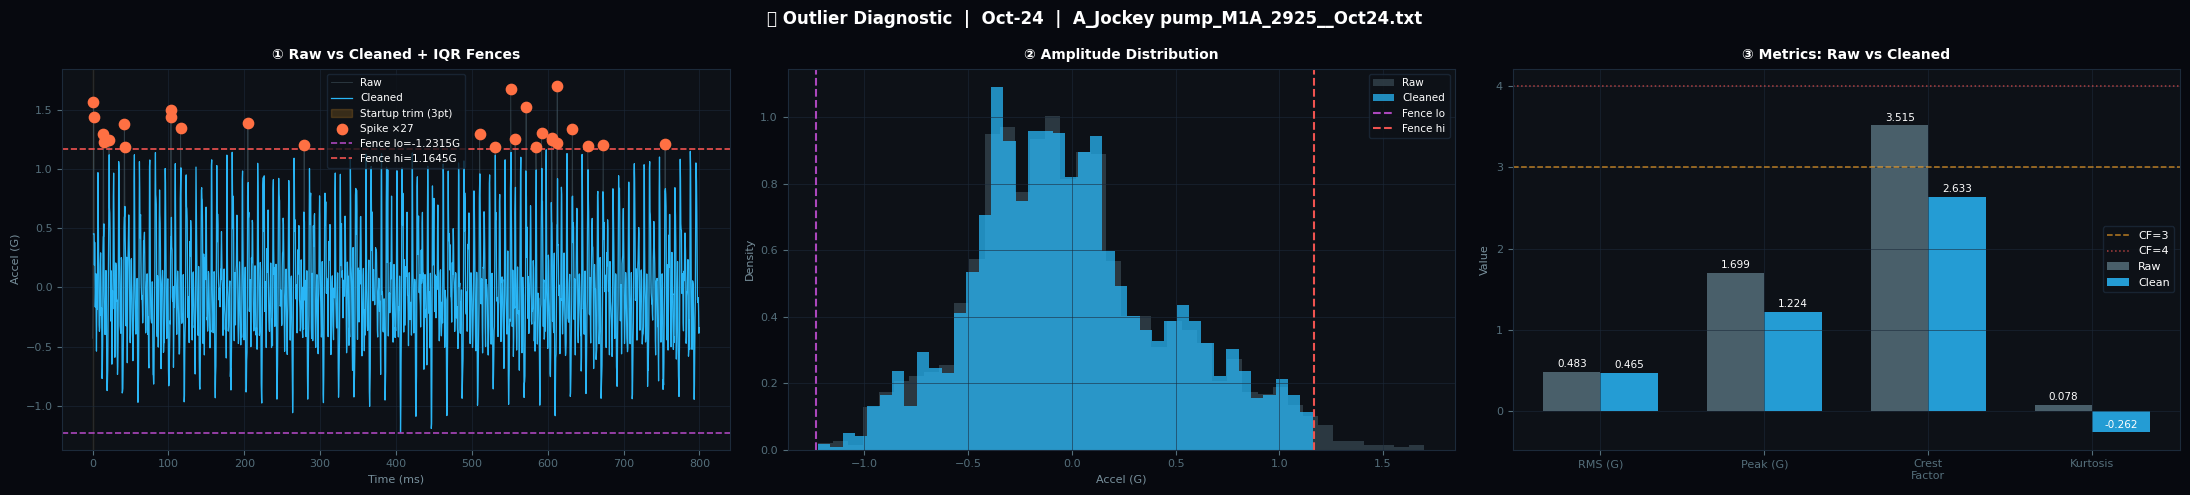

  💾 output\outlier_diag_Oct_24.png


──────────────────────────────────────────────────────────
  ── Sep-24  (A_Jockey pump_M1A_2925__Sep24.txt)
  RAW   N=2048  RMS=0.4691G  Peak=1.5310G  CF=3.264  Kurt=0.196
  [Sep-24] ✂ Startup trim: 3 pts
  [Sep-24] 🔧 Spikes: 29 pts  fence=[-1.185, 1.215]G
  CLEAN N=2045  RMS=0.4518G  Peak=1.2000G  CF=2.656  Kurt=-0.184  Zone B


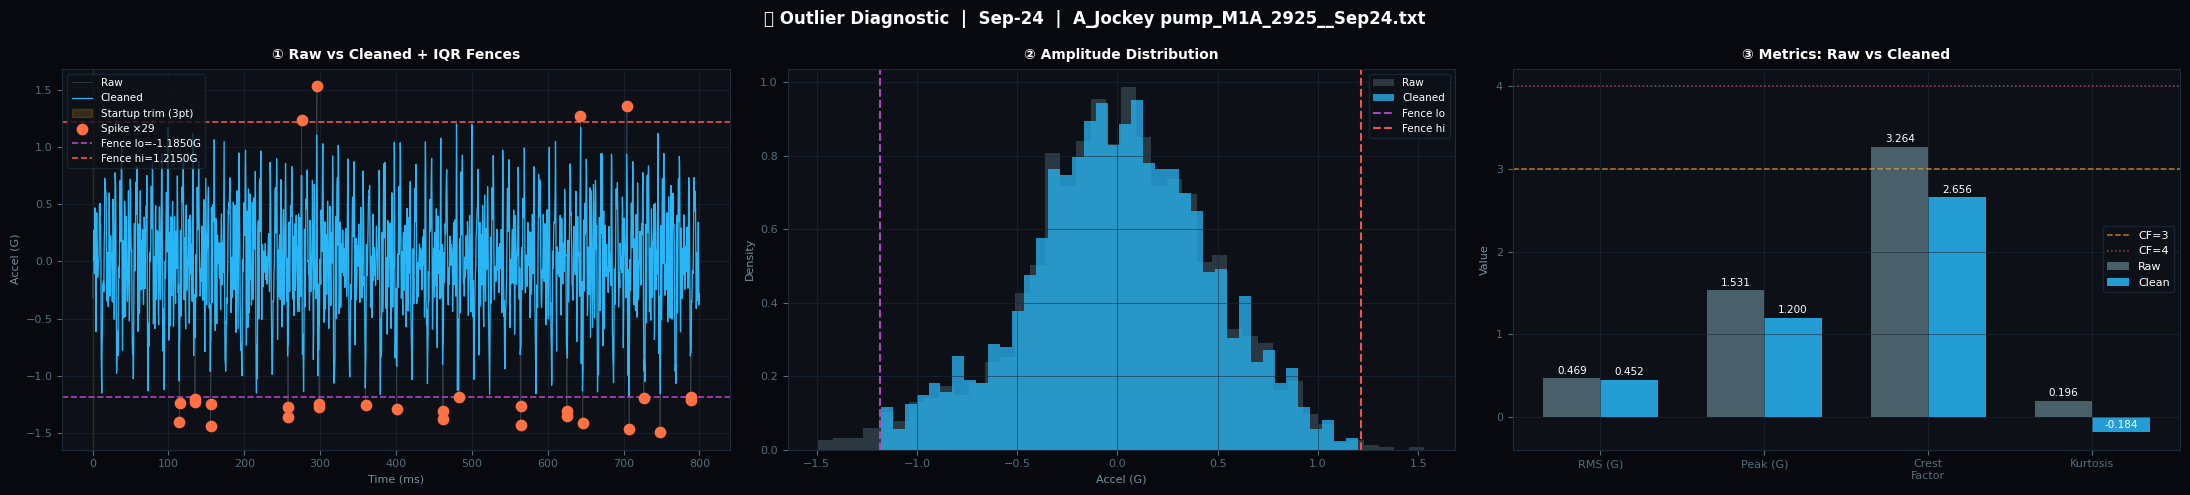

  💾 output\outlier_diag_Sep_24.png


✅ โหลดครบ 3 ไฟล์: Jun-24 → Sep-24 → Oct-24


In [6]:
DATE_FMTS = ['%d-%b-%y %H:%M:%S','%d-%b-%Y %H:%M:%S',
             '%d-%m-%Y %H:%M:%S','%Y-%m-%d %H:%M:%S']

def parse_dt(s):
    for fmt in DATE_FMTS:
        try: return datetime.strptime(s.strip(), fmt)
        except: pass
    return datetime.min

def plot_outlier_diag(label, fn, t_raw, a_raw, m_raw, t_c, a_c, m_cln, rpt):
    fence_lo = rpt.get('fence_lo')
    fence_hi = rpt.get('fence_hi')
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    fig.patch.set_facecolor('#07090f')
    fig.suptitle(f"🔍 Outlier Diagnostic  |  {label}  |  {fn}",
                 color='white', fontsize=12, fontweight='bold')
    ax1 = axes[0]; ax1.set_facecolor('#0d1117')
    ax1.plot(t_raw, a_raw, color='#455a64', lw=0.6, alpha=0.6, label='Raw')
    ax1.plot(t_c,   a_c,   color='#29b6f6', lw=0.9, label='Cleaned')
    if rpt['trimmed_count'] > 0:
        trim_end = t_raw[rpt['trimmed_count']] if rpt['trimmed_count'] < len(t_raw) else t_raw[-1]
        ax1.axvspan(t_raw[0], trim_end, alpha=0.18, color='#ffa726',
                    label=f"Startup trim ({rpt['trimmed_count']}pt)")
    if rpt['spike_count'] > 0:
        ax1.scatter(rpt['spike_times_ms'], rpt['spike_values_g'],
                    color='#ff7043', s=55, zorder=6, label=f"Spike ×{rpt['spike_count']}")
    if fence_lo is not None:
        ax1.axhline(fence_lo, color='#ab47bc', lw=1.2, ls='--', label=f"Fence lo={fence_lo:.4f}G")
    if fence_hi is not None:
        ax1.axhline(fence_hi, color='#ef5350', lw=1.2, ls='--', label=f"Fence hi={fence_hi:.4f}G")
    style_ax(ax1, '① Raw vs Cleaned + IQR Fences', 'Time (ms)', 'Accel (G)')
    ax1.legend(fontsize=7.5, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

    ax2 = axes[1]; ax2.set_facecolor('#0d1117')
    bins = min(120, max(30, len(a_raw)//50))
    ax2.hist(a_raw, bins=bins, color='#455a64', alpha=0.55, density=True, label='Raw')
    ax2.hist(a_c,   bins=bins, color='#29b6f6', alpha=0.75, density=True, label='Cleaned')
    if fence_lo is not None: ax2.axvline(fence_lo, color='#ab47bc', lw=1.5, ls='--', label='Fence lo')
    if fence_hi is not None: ax2.axvline(fence_hi, color='#ef5350', lw=1.5, ls='--', label='Fence hi')
    style_ax(ax2, '② Amplitude Distribution', 'Accel (G)', 'Density')
    ax2.legend(fontsize=7.5, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

    ax3 = axes[2]; ax3.set_facecolor('#0d1117')
    mlbls    = ['RMS (G)', 'Peak (G)', 'Crest\nFactor', 'Kurtosis']
    raw_vals = [m_raw['rms'], m_raw['peak'], m_raw['crest'], m_raw['kurt']]
    cln_vals = [m_cln['rms'], m_cln['peak'], m_cln['crest'], m_cln['kurt']]
    x3 = np.arange(len(mlbls)); w3 = 0.35
    b_raw = ax3.bar(x3-w3/2, raw_vals, w3, color='#546e7a', alpha=0.85, label='Raw')
    b_cln = ax3.bar(x3+w3/2, cln_vals, w3, color='#29b6f6', alpha=0.85, label='Clean')
    y_max = max(raw_vals + cln_vals)
    for bars, vals in [(b_raw, raw_vals),(b_cln, cln_vals)]:
        for b, v in zip(bars, vals):
            ax3.text(b.get_x()+b.get_width()/2, v+y_max*0.01,
                     f'{v:.3f}', ha='center', va='bottom', color='white', fontsize=7.5)
    ax3.axhline(3.0, color='#ffa726', lw=1.1, ls='--', alpha=0.7, label='CF=3')
    ax3.axhline(4.0, color='#ef5350', lw=1.1, ls=':',  alpha=0.7, label='CF=4')
    ax3.set_xticks(x3); ax3.set_xticklabels(mlbls, color='#cdd9e5', fontsize=9)
    style_ax(ax3, '③ Metrics: Raw vs Cleaned', '', 'Value')
    ax3.legend(fontsize=8, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

    plt.tight_layout()
    out_f = os.path.join(OUTPUT_DIR, f'outlier_diag_{label.replace("-","_")}.png')
    plt.savefig(out_f, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    display(fig); plt.close(fig)
    print(f"  💾 {out_f}\n")

# ── Main loop ─────────────────────────────────────────────────
if 'cleaning_reports' not in dir():
    cleaning_reports = []

print("=" * 62)
print("  🔍  Loading & Cleaning")
print("=" * 62)

all_ds = []
for fpath, fn in zip(file_paths, file_names):
    with open(fpath, 'rb') as f: content_bytes = f.read()
    meta, t_raw, a_raw = parse_waveform_txt(content_bytes)
    m_raw  = compute_metrics(a_raw, t_raw)
    dt_str = meta.get('datetime','')
    try:
        d = parse_dt(dt_str)
        month_from_file = fn.split('_')[-1][:3]
        if d.strftime('%b') != month_from_file: raise ValueError()
        label = d.strftime('%b-%y')
    except:
        m = re.search(r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)(\d{2})', fn)
        label = f"{m.group(1)}-{m.group(2)}" if m else fn[:10]

    print(f"\n{'─'*58}")
    print(f"  ── {label}  ({fn})")
    print(f"  RAW   N={len(a_raw)}  RMS={m_raw['rms']:.4f}G  "
          f"Peak={m_raw['peak']:.4f}G  CF={m_raw['crest']:.3f}  Kurt={m_raw['kurt']:.3f}")

    t_c, a_c, rpt = remove_outliers(t_raw, a_raw, label=label)
    cleaning_reports.append(rpt)  
    m_cln = compute_metrics(a_c, t_c)
    z, zinfo = iso_zone(m_cln['crest'])
    freq, fmag = compute_fft(a_c, m_cln['fs'])

    print(f"  CLEAN N={len(a_c)}  RMS={m_cln['rms']:.4f}G  "
          f"Peak={m_cln['peak']:.4f}G  CF={m_cln['crest']:.3f}  "
          f"Kurt={m_cln['kurt']:.3f}  Zone {z}")

    plot_outlier_diag(label, fn, t_raw, a_raw, m_raw, t_c, a_c, m_cln, rpt)

    all_ds.append({
        'label': label, 'dt_obj': parse_dt(dt_str),
        'fname': fn, 'meta': meta,
        'time_raw': t_raw, 'accel_raw': a_raw, 'metrics_raw': m_raw,
        'time': t_c, 'accel': a_c, 'metrics': m_cln,
        'outlier': rpt, 'iso_zone': z, 'iso_info': zinfo,
        'fft_freq': freq, 'fft_mag': fmag,
        'top_freqs': top_freqs(freq, fmag, n=8),
        'valid': True,   # ← default ทุกไฟล์ valid ก่อน
        'invalid_reason': '',
    })

all_ds.sort(key=lambda x: x['dt_obj'])
n_ds = len(all_ds)
COLORS = ['#29b6f6','#66bb6a','#ef5350','#ffa726','#ab47bc'][:n_ds]
labels_t = [ds['label'] for ds in all_ds]
print(f"\n✅ โหลดครบ {n_ds} ไฟล์: {' → '.join(labels_t)}")


---
## Session 3b — Raw Data Plots
> 4 subplot ต่อ 1 ไฟล์: Waveform / Zoom / FFT / Histogram+Stats

  📊  Raw Data Plots

  ── Jun-24


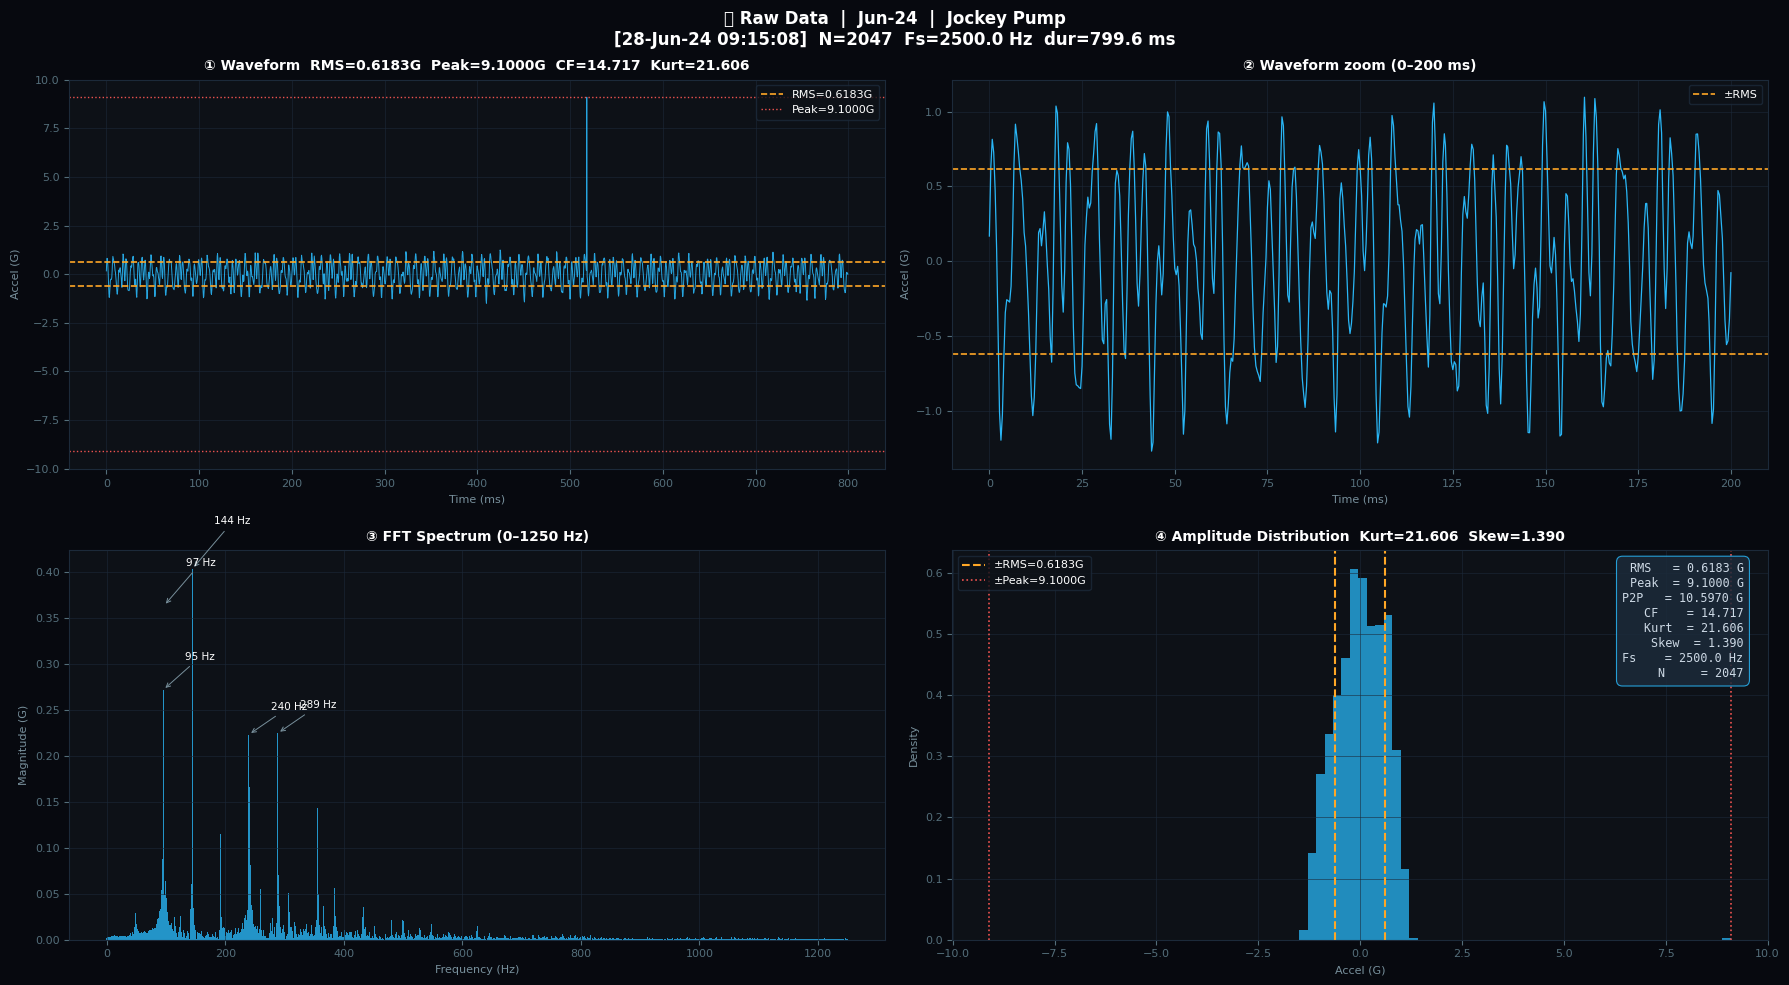

  💾 output\raw_data_Jun_24.png

  ── Sep-24


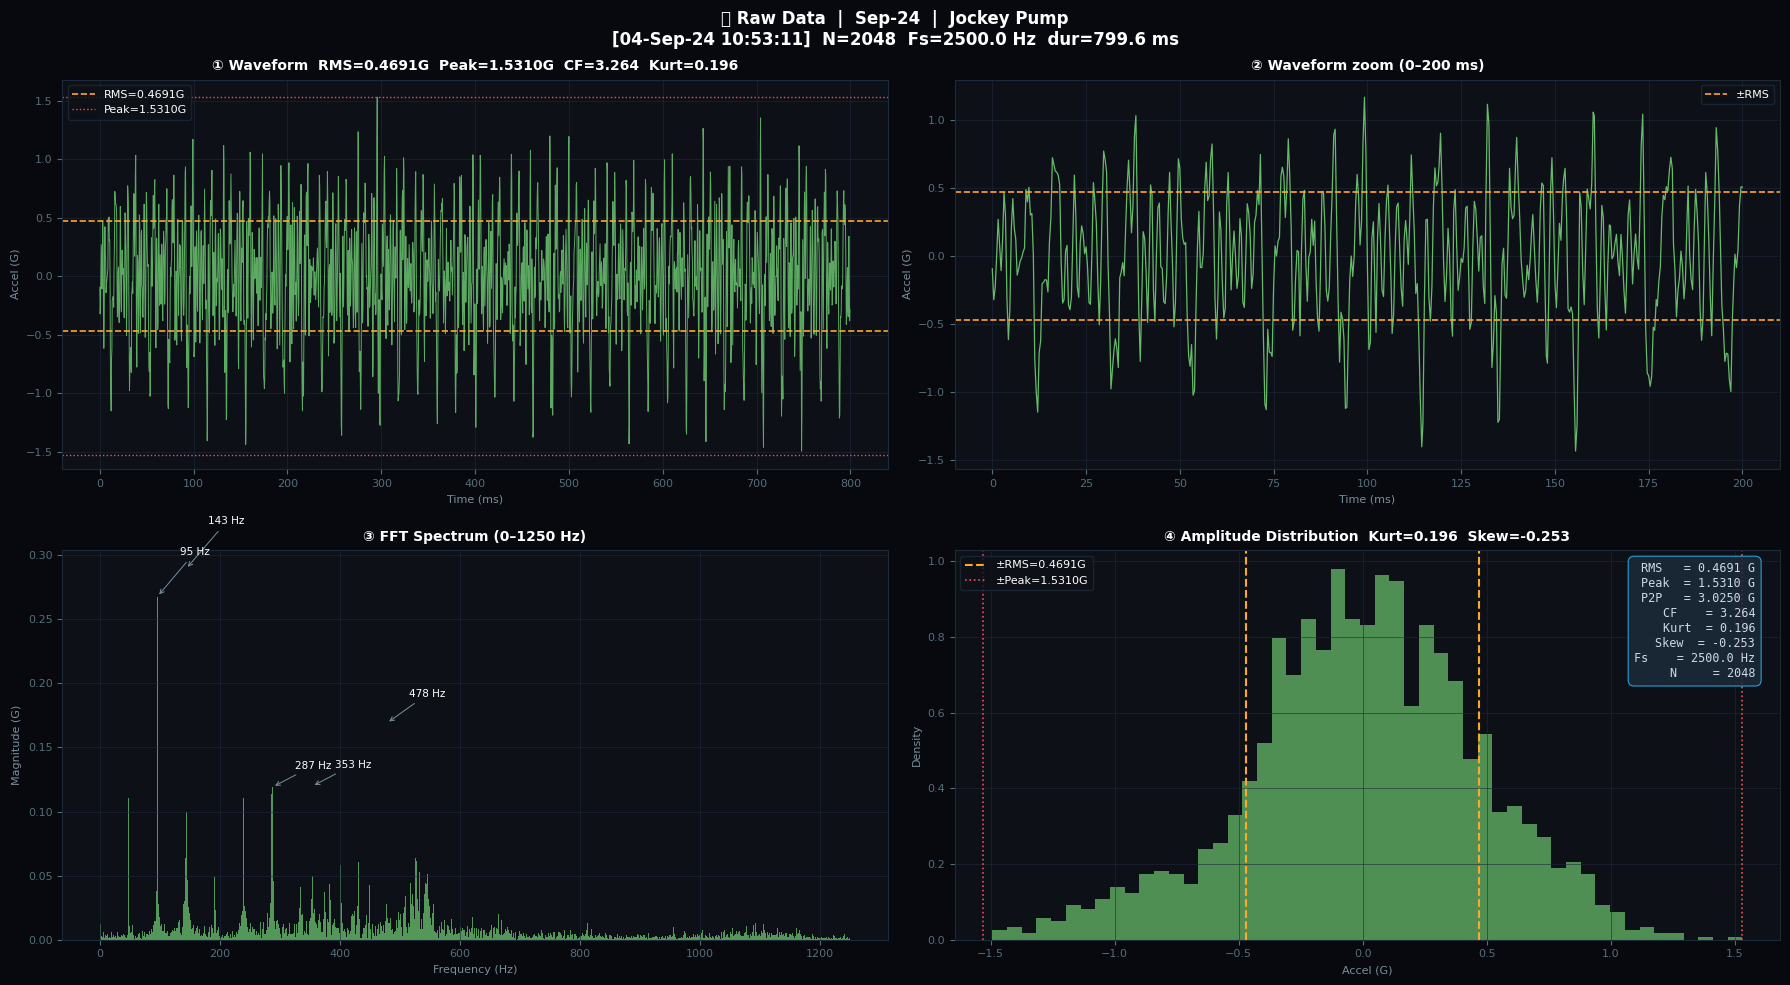

  💾 output\raw_data_Sep_24.png

  ── Oct-24


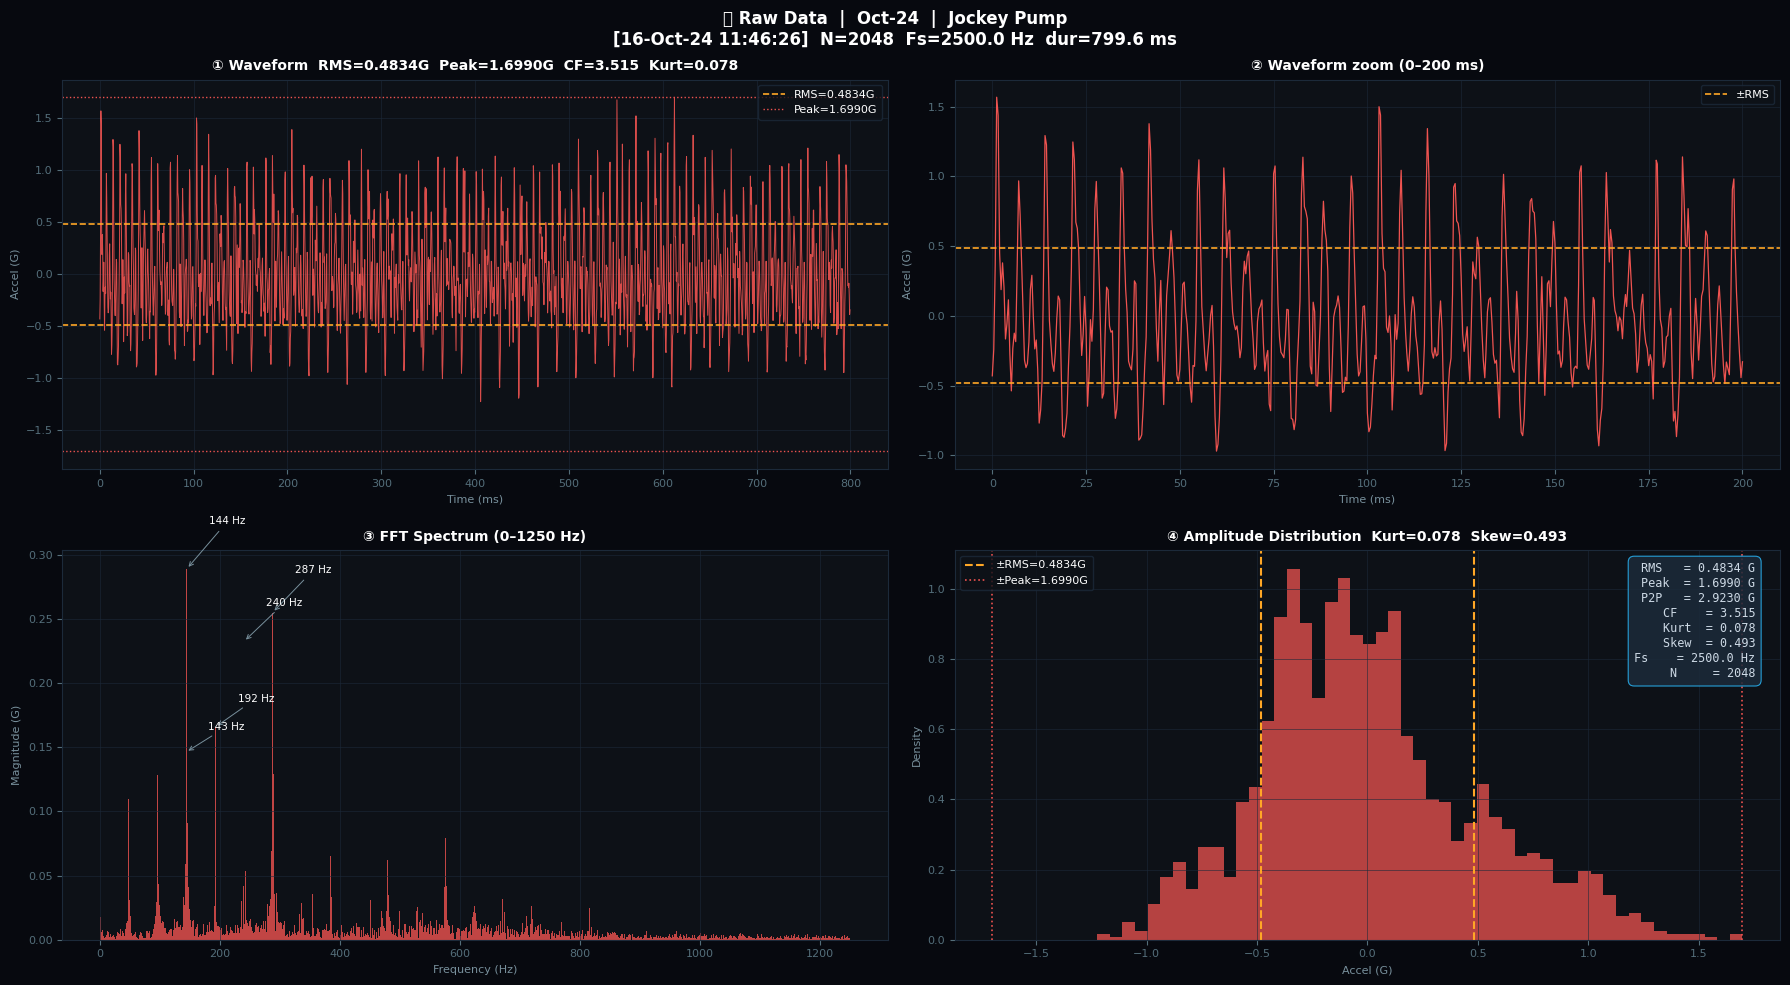

  💾 output\raw_data_Oct_24.png


In [7]:
def plot_raw_data(ds, color):
    label  = ds['label']
    t_raw  = ds['time_raw']; a_raw = ds['accel_raw']; m_raw = ds['metrics_raw']
    freq   = ds['fft_freq']; fmag  = ds['fft_mag']

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.patch.set_facecolor('#07090f')
    fig.suptitle(
        f"📊 Raw Data  |  {label}  |  {ds['meta'].get('equipment','—')}\n"
        f"[{ds['meta'].get('datetime','')}]  N={m_raw['n']}  "
        f"Fs={m_raw['fs']:.1f} Hz  dur={m_raw['dur']:.1f} ms",
        color='white', fontsize=12, fontweight='bold')

    # ① Waveform full
    ax1 = axes[0,0]; ax1.set_facecolor('#0d1117')
    ax1.plot(t_raw, a_raw, color=color, lw=0.7, alpha=0.9)
    ax1.axhline( m_raw['rms'],  color='#ffa726', lw=1.2, ls='--', label=f"RMS={m_raw['rms']:.4f}G")
    ax1.axhline(-m_raw['rms'],  color='#ffa726', lw=1.2, ls='--')
    ax1.axhline( m_raw['peak'], color='#ef5350', lw=1,   ls=':', label=f"Peak={m_raw['peak']:.4f}G")
    ax1.axhline(-m_raw['peak'], color='#ef5350', lw=1,   ls=':')
    style_ax(ax1, f"① Waveform  RMS={m_raw['rms']:.4f}G  Peak={m_raw['peak']:.4f}G  CF={m_raw['crest']:.3f}  Kurt={m_raw['kurt']:.3f}", 'Time (ms)', 'Accel (G)')
    ax1.legend(fontsize=8, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

    # ② Waveform zoom 200 ms
    ax2 = axes[0,1]; ax2.set_facecolor('#0d1117')
    mask200 = t_raw <= 200
    ax2.plot(t_raw[mask200], a_raw[mask200], color=color, lw=0.9)
    ax2.axhline( m_raw['rms'], color='#ffa726', lw=1.2, ls='--', label='±RMS')
    ax2.axhline(-m_raw['rms'], color='#ffa726', lw=1.2, ls='--')
    style_ax(ax2, '② Waveform zoom (0–200 ms)', 'Time (ms)', 'Accel (G)')
    ax2.legend(fontsize=8, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

    # ③ FFT
    ax3 = axes[1,0]; ax3.set_facecolor('#0d1117')
    fmax = min(m_raw['fs']/2, 2000)
    mask_f = freq <= fmax
    bw = freq[1]-freq[0] if len(freq)>1 else 1.
    ax3.bar(freq[mask_f], fmag[mask_f], width=bw, color=color, alpha=0.8, linewidth=0)
    for f0, m0 in top_freqs(freq, fmag, n=5):
        if f0 <= fmax:
            ax3.annotate(f'{f0:.0f} Hz', xy=(f0,m0), xytext=(f0+fmax*0.03, m0*1.12),
                         color='white', fontsize=7.5,
                         arrowprops=dict(arrowstyle='->', color='#78909c', lw=0.7))
    style_ax(ax3, f"③ FFT Spectrum (0–{fmax:.0f} Hz)", 'Frequency (Hz)', 'Magnitude (G)')

    # ④ Histogram + stats box
    ax4 = axes[1,1]; ax4.set_facecolor('#0d1117')
    bins = min(150, max(40, len(a_raw)//40))
    ax4.hist(a_raw, bins=bins, color=color, alpha=0.75, density=True, edgecolor='none')
    ax4.axvline( m_raw['rms'],  color='#ffa726', lw=1.5, ls='--', label=f"±RMS={m_raw['rms']:.4f}G")
    ax4.axvline(-m_raw['rms'],  color='#ffa726', lw=1.5, ls='--')
    ax4.axvline( m_raw['peak'], color='#ef5350', lw=1.2, ls=':', label=f"±Peak={m_raw['peak']:.4f}G")
    ax4.axvline(-m_raw['peak'], color='#ef5350', lw=1.2, ls=':')
    stats_txt = (f"RMS   = {m_raw['rms']:.4f} G\n"
                 f"Peak  = {m_raw['peak']:.4f} G\n"
                 f"P2P   = {m_raw['p2p']:.4f} G\n"
                 f"CF    = {m_raw['crest']:.3f}\n"
                 f"Kurt  = {m_raw['kurt']:.3f}\n"
                 f"Skew  = {m_raw['skew']:.3f}\n"
                 f"Fs    = {m_raw['fs']:.1f} Hz\n"
                 f"N     = {m_raw['n']}")
    ax4.text(0.97, 0.97, stats_txt, transform=ax4.transAxes, va='top', ha='right',
             fontsize=8.5, color='#cdd9e5', family='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#1c2a3a',
                       alpha=0.85, edgecolor='#29b6f6', lw=0.8))
    style_ax(ax4, f"④ Amplitude Distribution  Kurt={m_raw['kurt']:.3f}  Skew={m_raw['skew']:.3f}", 'Accel (G)', 'Density')
    ax4.legend(fontsize=8, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

    plt.tight_layout()
    out_f = os.path.join(OUTPUT_DIR, f'raw_data_{label.replace("-","_")}.png')
    plt.savefig(out_f, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    display(fig); plt.close(fig)
    print(f"  💾 {out_f}")

print("=" * 62)
print("  📊  Raw Data Plots")
print("=" * 62)
for ds, color in zip(all_ds, COLORS):
    print(f"\n  ── {ds['label']}")
    plot_raw_data(ds, color)


  Signal Quality Dashboard  (pre-cleaning)


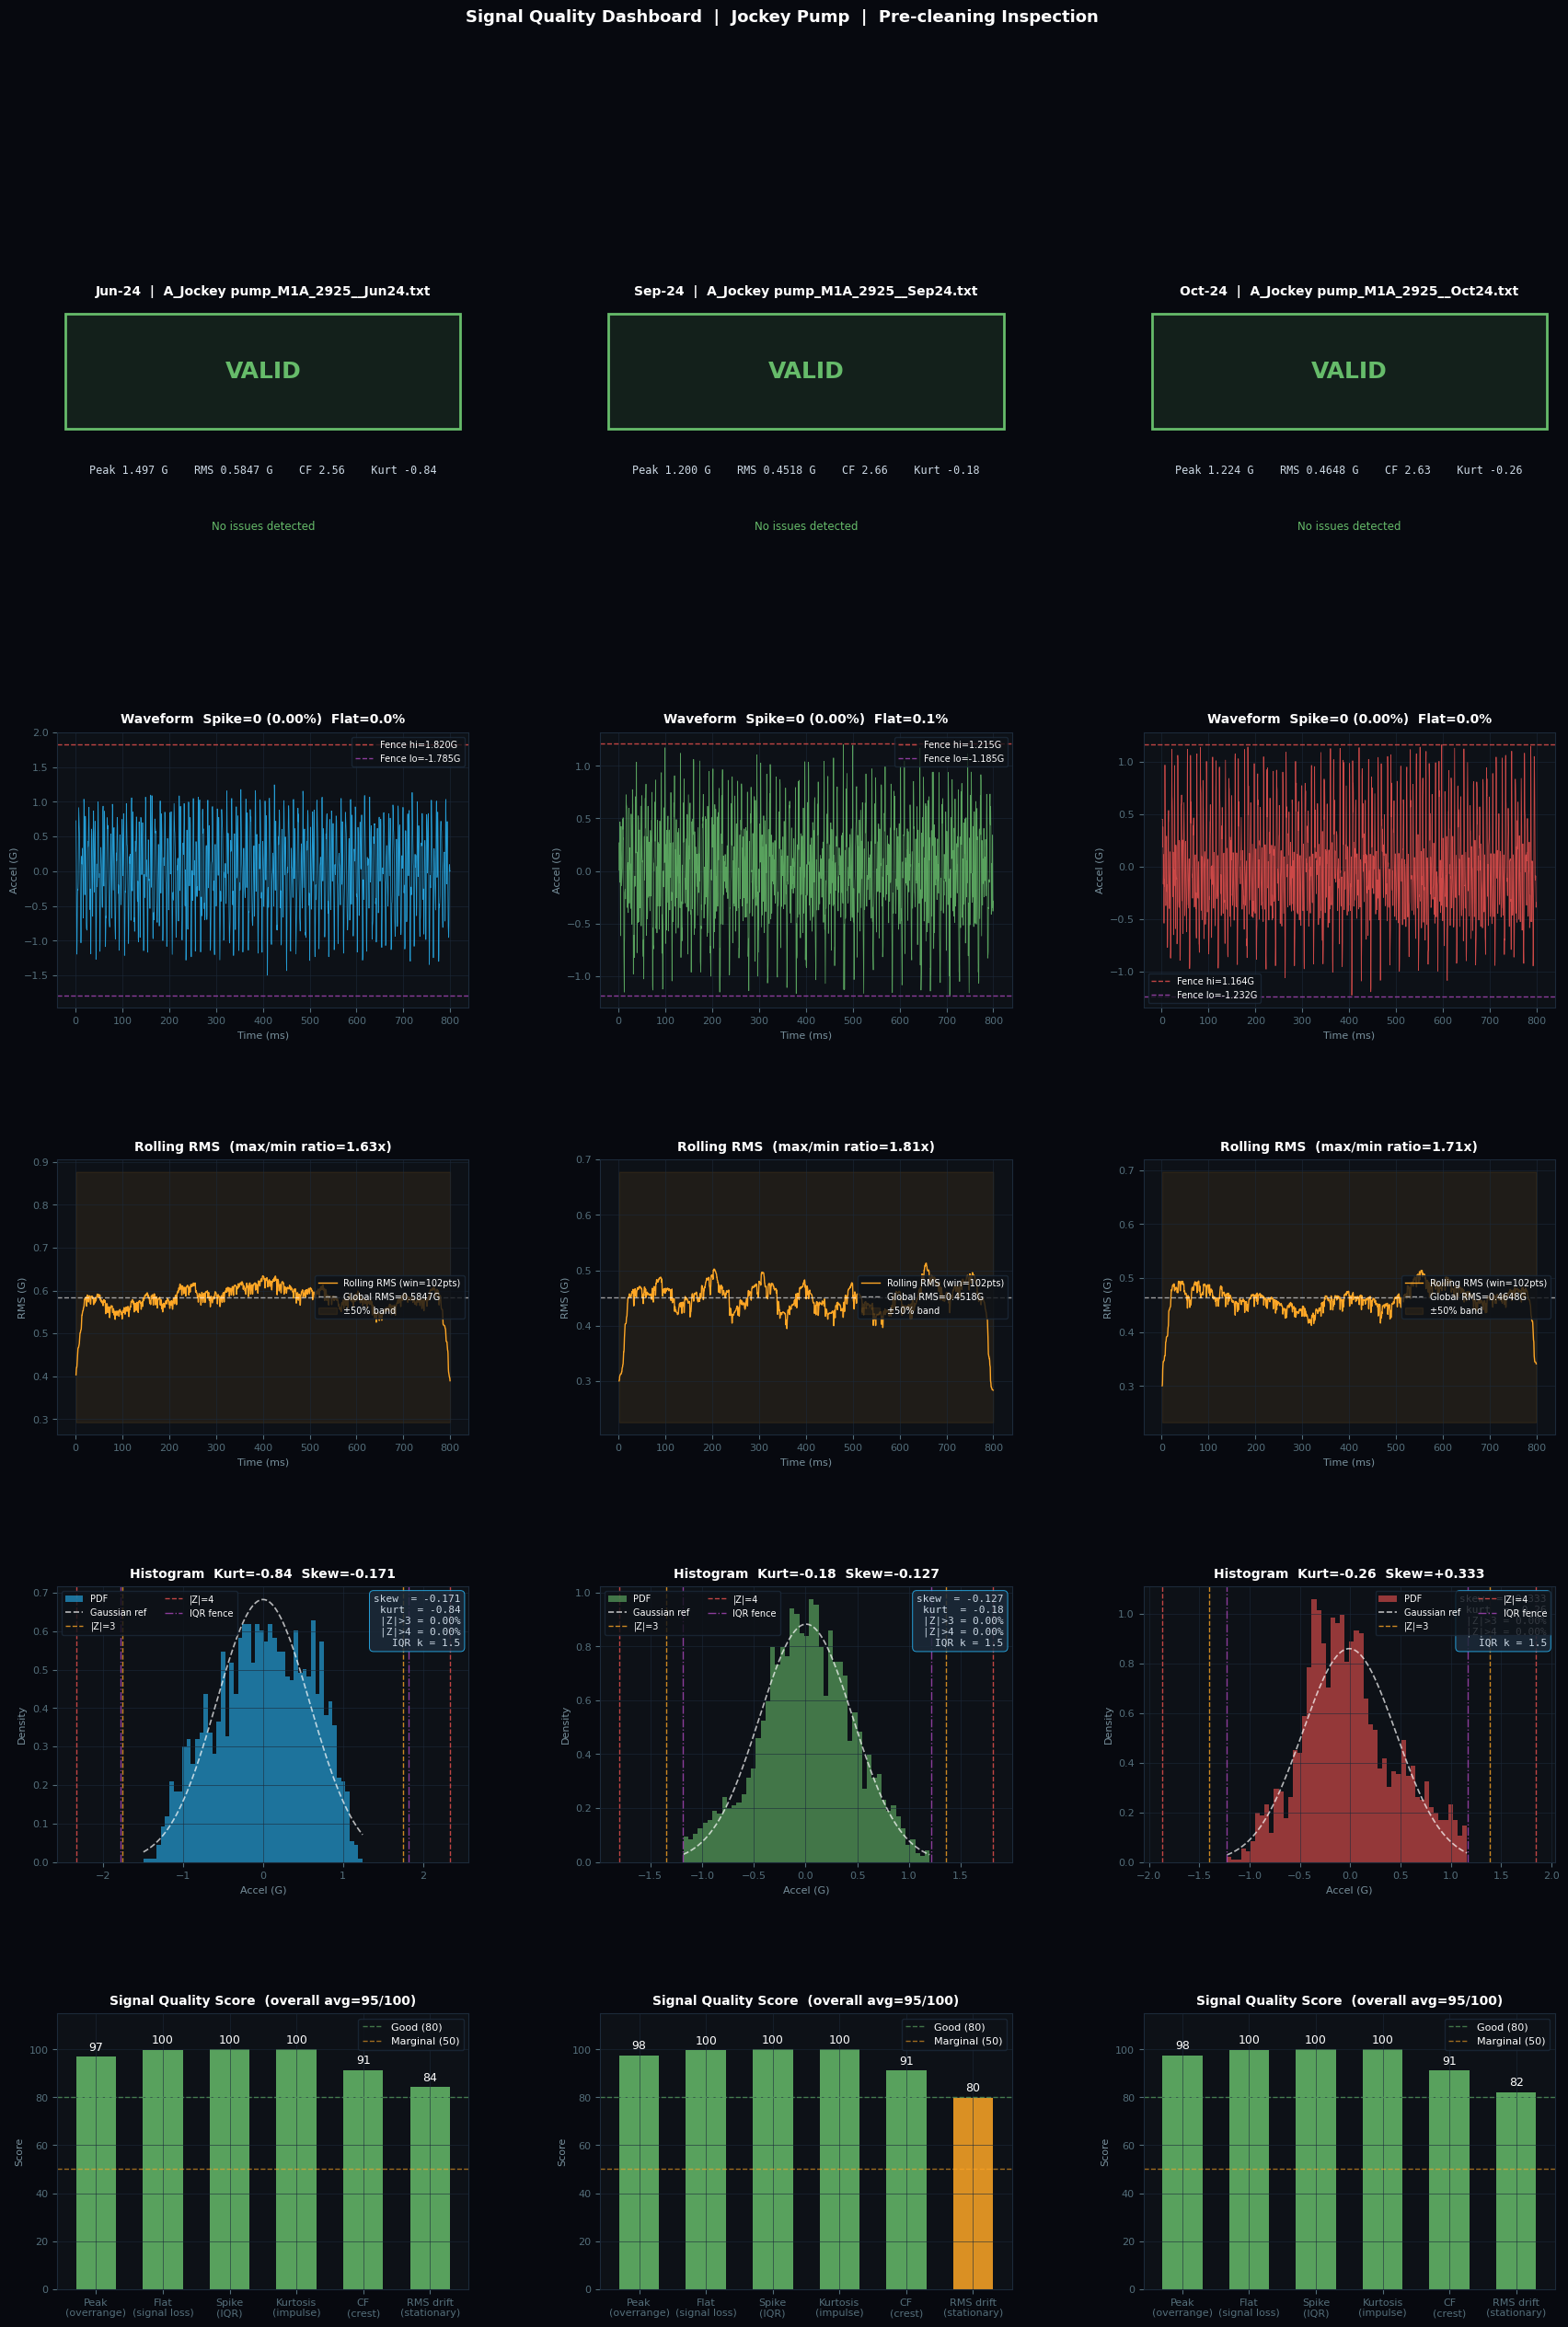

Saved: output\signal_quality_dashboard.png


In [8]:
# ════════════════════════════════════════════════════════════════
# Session 3c — Signal Quality Dashboard
# ดูว่าข้อมูลดิบเหมาะสำหรับ trend observation
# ════════════════════════════════════════════════════════════════

def signal_quality_dashboard(all_ds, colors):

    n = len(all_ds)
    fig = plt.figure(figsize=(7 * n, 28))
    fig.patch.set_facecolor('#07090f')
    gs = gridspec.GridSpec(5, n, figure=fig, hspace=0.55, wspace=0.32)

    for col, (ds, color) in enumerate(zip(all_ds, colors)):
        t  = ds['time']
        a  = ds['accel']
        fs = ds['metrics']['fs']
        N  = len(a)

        # ── Compute quality indicators ────────────────────────
        # IQR fence
        q1, q3 = np.percentile(a, 25), np.percentile(a, 75)
        iqr    = q3 - q1
        lo     = q1 - IQR_MULTIPLIER * iqr
        hi     = q3 + IQR_MULTIPLIER * iqr
        spike_mask = (a < lo) | (a > hi)
        n_spike    = int(np.sum(spike_mask))
        spike_pct  = n_spike / N * 100

        # Flat signal
        flat_mask = np.abs(a) < 0.001
        flat_pct  = float(np.sum(flat_mask)) / N * 100

        # Z-score
        mu, sigma = np.mean(a), np.std(a)
        z = (a - mu) / (sigma + 1e-12)

        # Rolling RMS (window = 5% of signal)
        win = max(50, N // 20)
        a_sq     = a ** 2
        rms_roll = np.sqrt(np.convolve(a_sq,
                           np.ones(win)/win, mode='same'))
        rms_global = float(np.sqrt(np.mean(a_sq)))
        rms_ratio  = rms_roll.max() / (rms_roll.min() + 1e-9)

        # Global stats
        cf       = ds['metrics']['crest']
        kurt_val = ds['metrics']['kurt']
        peak     = ds['metrics']['peak']
        rms_val  = ds['metrics']['rms']

        # ── Verdict ───────────────────────────────────────────
        issues = []
        if peak > 50:
            issues.append(f"Peak={peak:.1f}G (>50G overrange)")
        if flat_pct > 30:
            issues.append(f"Flat={flat_pct:.1f}% (signal loss)")
        if kurt_val > 500:
            issues.append(f"Kurt={kurt_val:.0f} (single impulse)")
        if cf > 30:
            issues.append(f"CF={cf:.1f} (not continuous vibration)")
        if spike_pct > 5:
            issues.append(f"Spikes={spike_pct:.1f}% (>5% removed)")
        if rms_ratio > 5:
            issues.append(f"RMS drift={rms_ratio:.1f}x (non-stationary)")

        verdict      = "INVALID" if issues else "VALID"
        verdict_color = '#ef5350' if issues else '#66bb6a'
        label        = ds['label']

        # ════════════════════════════════════════════════════
        # Row 0: Scorecard header
        # ════════════════════════════════════════════════════
        ax0 = fig.add_subplot(gs[0, col])
        ax0.set_facecolor('#0d1117')
        ax0.axis('off')

        # Verdict box
        ax0.add_patch(plt.Rectangle(
            (0.02, 0.55), 0.96, 0.42,
            transform=ax0.transAxes,
            facecolor=verdict_color + '22',
            edgecolor=verdict_color, lw=2,
            clip_on=False))
        ax0.text(0.5, 0.76,
                 verdict,
                 transform=ax0.transAxes,
                 ha='center', va='center',
                 color=verdict_color,
                 fontsize=18, fontweight='bold')

        # Metric pills
        metrics_txt = (
            f"Peak {peak:.3f} G    "
            f"RMS {rms_val:.4f} G    "
            f"CF {cf:.2f}    "
            f"Kurt {kurt_val:.2f}"
        )
        ax0.text(0.5, 0.40, metrics_txt,
                 transform=ax0.transAxes,
                 ha='center', va='center',
                 color='#cdd9e5', fontsize=8.5,
                 family='monospace')

        # Issues list
        if issues:
            for i, iss in enumerate(issues):
                ax0.text(0.5, 0.28 - i * 0.10,
                         f"  {iss}",
                         transform=ax0.transAxes,
                         ha='center', va='top',
                         color='#ef5350', fontsize=8)
        else:
            ax0.text(0.5, 0.22,
                     "No issues detected",
                     transform=ax0.transAxes,
                     ha='center', va='top',
                     color='#66bb6a', fontsize=8.5)

        ax0.set_title(f"{label}  |  {ds['fname']}",
                      color='white', fontsize=10,
                      fontweight='bold', pad=8)

        # ════════════════════════════════════════════════════
        # Row 1: Waveform + IQR fence + flat shading
        # ════════════════════════════════════════════════════
        ax1 = fig.add_subplot(gs[1, col])
        ax1.set_facecolor('#0d1117')
        ax1.plot(t, a, color=color, lw=0.55, alpha=0.85)

        # IQR fence
        ax1.axhline(hi, color='#ef5350', lw=1.0, ls='--',
                    alpha=0.8, label=f'Fence hi={hi:.3f}G')
        ax1.axhline(lo, color='#ab47bc', lw=1.0, ls='--',
                    alpha=0.8, label=f'Fence lo={lo:.3f}G')

        # Spike markers
        if n_spike > 0:
            ax1.scatter(t[spike_mask], a[spike_mask],
                        color='#ff7043', s=50, zorder=6,
                        label=f'Spike x{n_spike}')

        # Flat shading (รวม consecutive regions)
        if flat_pct > 0.5:
            diff  = np.diff(flat_mask.astype(int))
            starts = np.where(diff == 1)[0] + 1
            ends   = np.where(diff == -1)[0] + 1
            if flat_mask[0]:  starts = np.r_[0, starts]
            if flat_mask[-1]: ends   = np.r_[ends, N]
            for s, e in zip(starts, ends):
                ax1.axvspan(t[s], t[min(e, N-1)],
                            alpha=0.25, color='#546e7a',
                            label='_nolegend_')
            ax1.axvspan(0, 0, alpha=0.25, color='#546e7a',
                        label=f'Flat {flat_pct:.1f}%')

        style_ax(ax1,
                 f'Waveform  Spike={n_spike} ({spike_pct:.2f}%)  '
                 f'Flat={flat_pct:.1f}%',
                 'Time (ms)', 'Accel (G)')
        ax1.legend(fontsize=7, facecolor='#0d1117',
                   edgecolor='#1c2a3a', labelcolor='white')

        # ════════════════════════════════════════════════════
        # Row 2: Rolling RMS (stationarity check)
        # ════════════════════════════════════════════════════
        ax2 = fig.add_subplot(gs[2, col])
        ax2.set_facecolor('#0d1117')
        ax2.plot(t, rms_roll, color='#ffa726', lw=1.0,
                 label=f'Rolling RMS (win={win}pts)')
        ax2.axhline(rms_global, color='white', lw=1.0, ls='--',
                    alpha=0.6, label=f'Global RMS={rms_global:.4f}G')

        # Band: global ±50%
        ax2.fill_between(t,
                         rms_global * 0.5,
                         rms_global * 1.5,
                         alpha=0.08, color='#ffa726',
                         label='±50% band')

        # Flag drift
        drift_flag = (f'  DRIFT {rms_ratio:.1f}x'
                      if rms_ratio > 3 else '')
        style_ax(ax2,
                 f'Rolling RMS  (max/min ratio={rms_ratio:.2f}x){drift_flag}',
                 'Time (ms)', 'RMS (G)')
        ax2.legend(fontsize=7, facecolor='#0d1117',
                   edgecolor='#1c2a3a', labelcolor='white')

        # ════════════════════════════════════════════════════
        # Row 3: Histogram + Gaussian + Z-score bands
        # ════════════════════════════════════════════════════
        ax3 = fig.add_subplot(gs[3, col])
        ax3.set_facecolor('#0d1117')
        bins = min(150, max(40, N // 40))
        ax3.hist(a, bins=bins, color=color, alpha=0.6,
                 density=True, label='PDF')

        # Gaussian reference
        from scipy.stats import norm
        x_g = np.linspace(a.min(), a.max(), 400)
        ax3.plot(x_g, norm.pdf(x_g, mu, sigma),
                 color='white', lw=1.2, ls='--',
                 alpha=0.7, label='Gaussian ref')

        # Z-score shading
        for z_thresh, c_z, lbl_z in [
            (3.0, '#ffa726', '|Z|=3'),
            (4.0, '#ef5350', '|Z|=4'),
        ]:
            ax3.axvline(mu + z_thresh * sigma,
                        color=c_z, lw=1.0, ls='--',
                        alpha=0.8, label=lbl_z)
            ax3.axvline(mu - z_thresh * sigma,
                        color=c_z, lw=1.0, ls='--',
                        alpha=0.8, label='_nolegend_')

        # IQR fence
        ax3.axvline(hi, color='#ab47bc', lw=1.0, ls='-.',
                    alpha=0.8, label='IQR fence')
        ax3.axvline(lo, color='#ab47bc', lw=1.0, ls='-.',
                    alpha=0.8, label='_nolegend_')

        # Stats annotation
        skew_v = float(skew(a))
        pct_z3 = np.sum(np.abs(z) > 3) / N * 100
        pct_z4 = np.sum(np.abs(z) > 4) / N * 100
        stats  = (f"skew  = {skew_v:+.3f}\n"
                  f"kurt  = {kurt_val:.2f}\n"
                  f"|Z|>3 = {pct_z3:.2f}%\n"
                  f"|Z|>4 = {pct_z4:.2f}%\n"
                  f"IQR k = {IQR_MULTIPLIER}")
        ax3.text(0.98, 0.97, stats,
                 transform=ax3.transAxes,
                 va='top', ha='right', fontsize=8,
                 color='#cdd9e5', family='monospace',
                 bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='#1c2a3a', alpha=0.85,
                           edgecolor='#29b6f6', lw=0.7))
        style_ax(ax3,
                 f'Histogram  Kurt={kurt_val:.2f}  '
                 f'Skew={skew_v:+.3f}',
                 'Accel (G)', 'Density')
        ax3.legend(fontsize=7, facecolor='#0d1117',
                   edgecolor='#1c2a3a', labelcolor='white',
                   ncol=2)

        # ════════════════════════════════════════════════════
        # Row 4: Quality score bar
        # ════════════════════════════════════════════════════
        ax4 = fig.add_subplot(gs[4, col])
        ax4.set_facecolor('#0d1117')

        # คะแนนแต่ละด้าน (0–100 ดีที่สุด)
        score_items = {
            'Peak\n(overrange)':
                max(0, 100 - peak / 50 * 100),
            'Flat\n(signal loss)':
                max(0, 100 - flat_pct / 30 * 100),
            'Spike\n(IQR)':
                max(0, 100 - spike_pct / 5 * 100),
            'Kurtosis\n(impulse)':
                max(0, 100 - kurt_val / 500 * 100),
            'CF\n(crest)':
                max(0, 100 - cf / 30 * 100),
            'RMS drift\n(stationary)':
                max(0, 100 - (rms_ratio - 1) / 4 * 100),
        }

        names  = list(score_items.keys())
        scores = [min(100, v) for v in score_items.values()]
        x_pos  = np.arange(len(names))
        bar_cols = ['#66bb6a' if s >= 80
                    else '#ffa726' if s >= 50
                    else '#ef5350'
                    for s in scores]

        bars = ax4.bar(x_pos, scores, color=bar_cols,
                       alpha=0.85, width=0.6)
        for b, s in zip(bars, scores):
            ax4.text(b.get_x() + b.get_width() / 2,
                     s + 1.5,
                     f'{s:.0f}',
                     ha='center', va='bottom',
                     color='white', fontsize=9)

        ax4.axhline(80, color='#66bb6a', lw=1.0, ls='--',
                    alpha=0.6, label='Good (80)')
        ax4.axhline(50, color='#ffa726', lw=1.0, ls='--',
                    alpha=0.6, label='Marginal (50)')
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(names, color='#cdd9e5',
                             fontsize=8)
        ax4.set_ylim(0, 115)
        overall = np.mean(scores)
        style_ax(ax4,
                 f'Signal Quality Score  '
                 f'(overall avg={overall:.0f}/100)',
                 '', 'Score')
        ax4.legend(fontsize=8, facecolor='#0d1117',
                   edgecolor='#1c2a3a', labelcolor='white')

    fig.suptitle(
        f"Signal Quality Dashboard  |  "
        f"{all_ds[0]['meta'].get('equipment','—')}  |  "
        f"Pre-cleaning Inspection",
        color='white', fontsize=13, fontweight='bold',
        y=0.995)

    plt.tight_layout()
    out_f = os.path.join(OUTPUT_DIR,
                         'signal_quality_dashboard.png')
    plt.savefig(out_f, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    display(fig)
    plt.close(fig)
    print(f"Saved: {out_f}")


# ── Run ──────────────────────────────────────────────────────
print("=" * 62)
print("  Signal Quality Dashboard  (pre-cleaning)")
print("=" * 62)
signal_quality_dashboard(all_ds, COLORS)

---
## Session 3c — Outlier Removal Audit
> 🛡️ ตรวจสอบรายการข้อมูลที่ถูกแก้ไขและเปรียบเทียบค่าทางสถิติ

In [9]:
audit_data = []

print("=" * 62)
print("  📊  Outlier Removal Audit Report")
print("=" * 62)

for rpt in cleaning_reports:
    lbl = rpt.get("label", "Unknown")
    n_spikes = rpt.get("spike_count", 0)
    
    print(f"\n>>> FILE: {lbl}")
    if n_spikes > 0:
        print(f"   Detected {n_spikes} spikes:")
        for t_ms, val in zip(rpt["spike_times_ms"], rpt["spike_values_g"]):
            print(f"      - at {t_ms:>8.2f} ms: {val:>10.4f} G")
    else:
        print("   ✅ No spikes detected.")
    
    # For Summary Table
    audit_data.append({
        "File": lbl,
        "Total_Pts": rpt["n_raw"],
        "Trimmed": rpt["trimmed_count"],
        "Spikes": rpt["spike_count"],
        "Peak_Raw": rpt["spike_max_raw"],
        "Peak_Clean": rpt["peak_after"],
        "RMS_Clean": rpt["rms_after"]
    })

# Display Summary Table
df_audit = pd.DataFrame(audit_data)
print("\n" + "-"*30)
print("  Summary Comparison Table")
print("-"*30)
display(df_audit.style.set_caption("Raw vs Cleaned Audit Summary"))

  📊  Outlier Removal Audit Report

>>> FILE: Jun-24
   Detected 1 spikes:
      - at   518.00 ms:     9.1000 G

>>> FILE: Oct-24
   Detected 27 spikes:
      - at     1.17 ms:     1.5680 G
      - at     1.56 ms:     1.4370 G
      - at    14.06 ms:     1.2930 G
      - at    14.45 ms:     1.2260 G
      - at    21.48 ms:     1.2470 G
      - at    41.80 ms:     1.3780 G
      - at    42.19 ms:     1.1880 G
      - at   103.10 ms:     1.5000 G
      - at   103.50 ms:     1.4400 G
      - at   116.00 ms:     1.3430 G
      - at   204.70 ms:     1.3880 G
      - at   278.90 ms:     1.2000 G
      - at   510.20 ms:     1.2970 G
      - at   530.50 ms:     1.1880 G
      - at   551.20 ms:     1.6740 G
      - at   557.00 ms:     1.2490 G
      - at   571.50 ms:     1.5200 G
      - at   584.40 ms:     1.1840 G
      - at   591.80 ms:     1.3050 G
      - at   605.10 ms:     1.2410 G
      - at   605.50 ms:     1.2620 G
      - at   612.10 ms:     1.2210 G
      - at   612.50 ms:     1.6990

,File,Total_Pts,Trimmed,Spikes,Peak_Raw,Peak_Clean,RMS_Clean
0,Jun-24,2047,3,1,9.100000,1.497000,0.584680
1,Oct-24,2048,3,27,1.699000,1.224000,0.464800
2,Sep-24,2048,3,29,1.531000,1.200000,0.451830


---
## Session 4 — Data Validation
> ตรวจสอบและ flag ไฟล์ที่ข้อมูลเสียหายก่อนวิเคราะห์
>
> **เกณฑ์ที่ใช้ตรวจ (ปรับได้):**
> - `PEAK_MAX_G` — Peak raw เกินนี้ถือว่า sensor fault / overrange
> - `CF_RAW_MAX` — CF raw เกินนี้ถือว่าผิดปกติมาก
> - `KURT_RAW_MAX` — Kurtosis raw เกินนี้ถือว่า impulse เดี่ยว ไม่ใช่ vibration
> - `FLAT_RATIO_MAX` — สัดส่วนจุดที่ = 0 เกินนี้ถือว่า signal หาย


In [10]:
# ▶▶▶  ปรับเกณฑ์ตรงนี้ได้  ◀◀◀
PEAK_MAX_G    = 50.0    # G  — เกินนี้ถือว่า sensor overrange
CF_RAW_MAX    = 30.0    # —  — CF raw เกินนี้ผิดปกติมาก
KURT_RAW_MAX  = 500.0   # —  — Kurtosis raw เกินนี้ถือว่า impulse เดี่ยว
FLAT_RATIO_MAX = 0.30   # —  — จุดที่ |a| < 0.001G เกิน 30% ถือว่า signal หาย

# ════════════════════════════════════════════════════════════════
# ตรวจแต่ละไฟล์
# ════════════════════════════════════════════════════════════════
print("=" * 70)
print("  🔎  DATA VALIDATION")
print("=" * 70)

val_rows = []
for ds in all_ds:
    mr   = ds['metrics']
    a_r  = ds['accel']
    reasons = []

    # เกณฑ์ 1: Peak overrange
    if mr['peak'] > PEAK_MAX_G:
        reasons.append(f"Peak={mr['peak']:.1f}G > {PEAK_MAX_G}G (sensor overrange?)")

    # เกณฑ์ 2: CF raw สูงผิดปกติ
    if mr['crest'] > CF_RAW_MAX:
        reasons.append(f"CF_raw={mr['crest']:.1f} > {CF_RAW_MAX} (impulse/fault)")

    # เกณฑ์ 3: Kurtosis สูงมาก → impulse เดี่ยว ไม่ใช่ vibration ต่อเนื่อง
    if mr['kurt'] > KURT_RAW_MAX:
        reasons.append(f"Kurtosis_raw={mr['kurt']:.1f} > {KURT_RAW_MAX} (single impulse?)")

    # เกณฑ์ 4: Flat signal (ข้อมูลหาย)
    flat_ratio = float(np.sum(np.abs(a_r) < 0.001) / len(a_r))
    if flat_ratio > FLAT_RATIO_MAX:
        reasons.append(f"Flat ratio={flat_ratio:.1%} > {FLAT_RATIO_MAX:.0%} (signal lost?)")

    # เกณฑ์ 5: สัดส่วนจุดที่ถูก remove หลัง clean สูงมาก
    n_removed = ds['outlier']['trimmed_count'] + ds['outlier']['spike_count']
    remove_pct = n_removed / mr['n'] * 100
    if remove_pct > 5.0:
        reasons.append(f"Removed={remove_pct:.1f}% of signal (>5%)")

    is_valid = len(reasons) == 0
    ds['valid']          = is_valid
    ds['invalid_reason'] = ' | '.join(reasons)
    ds['remove_pct']     = round(remove_pct, 2)

    status = "✅ VALID" if is_valid else "🔴 INVALID"
    print(f"\n  {ds['label']} ({ds['fname']})")
    print(f"    Status : {status}")
    print(f"    Peak   = {mr['peak']:.4f} G  |  CF_raw = {mr['crest']:.3f}  "
          f"|  Kurt_raw = {mr['kurt']:.3f}  |  Flat = {flat_ratio:.1%}")
    if not is_valid:
        for r in reasons:
            print(f"    ⚠  {r}")

    val_rows.append({
        'Period':       ds['label'],
        'File':         ds['fname'],
        'Valid':        'Yes' if is_valid else 'No',
        'Peak raw (G)': round(mr['peak'],4),
        'CF raw':       round(mr['crest'],4),
        'Kurt raw':     round(mr['kurt'],4),
        'Flat ratio':   round(flat_ratio,4),
        'Removed %':    round(remove_pct,2),
        'Reason':       ds['invalid_reason'],
    })

df_validation = pd.DataFrame(val_rows)

# ── สรุปผล ────────────────────────────────────────────────────
n_valid   = sum(1 for ds in all_ds if ds['valid'])
n_invalid = n_ds - n_valid
print(f"\n{'='*70}")
print(f"  สรุป: Valid={n_valid}  Invalid={n_invalid}  จากทั้งหมด {n_ds} ไฟล์")
if n_invalid > 0:
    inv_labels = [ds['label'] for ds in all_ds if not ds['valid']]
    print(f"  ⚠  ไฟล์ที่ invalid: {', '.join(inv_labels)}")
    print(f"  ⚠  ไฟล์เหล่านี้จะถูก EXCLUDE ออกจากการวิเคราะห์ใน Session 5 เป็นต้นไป")
    print(f"  ℹ  ถ้าต้องการรวมไฟล์นั้นด้วย ให้ปรับเกณฑ์ด้านบนแล้วรัน cell นี้ใหม่")
print(f"{'='*70}")
print(df_validation.to_string(index=False))


  🔎  DATA VALIDATION

  Jun-24 (A_Jockey pump_M1A_2925__Jun24.txt)
    Status : ✅ VALID
    Peak   = 1.4970 G  |  CF_raw = 2.560  |  Kurt_raw = -0.842  |  Flat = 0.0%

  Sep-24 (A_Jockey pump_M1A_2925__Sep24.txt)
    Status : ✅ VALID
    Peak   = 1.2000 G  |  CF_raw = 2.656  |  Kurt_raw = -0.184  |  Flat = 0.1%

  Oct-24 (A_Jockey pump_M1A_2925__Oct24.txt)
    Status : ✅ VALID
    Peak   = 1.2240 G  |  CF_raw = 2.633  |  Kurt_raw = -0.262  |  Flat = 0.0%

  สรุป: Valid=3  Invalid=0  จากทั้งหมด 3 ไฟล์
Period                              File Valid  Peak raw (G)  CF raw  Kurt raw  Flat ratio  Removed % Reason
Jun-24 A_Jockey pump_M1A_2925__Jun24.txt   Yes         1.497  2.5604   -0.8419      0.0005       0.20       
Sep-24 A_Jockey pump_M1A_2925__Sep24.txt   Yes         1.200  2.6559   -0.1840      0.0010       1.56       
Oct-24 A_Jockey pump_M1A_2925__Oct24.txt   Yes         1.224  2.6334   -0.2618      0.0005       1.47       


### 4b — เลือก Dataset ที่จะใช้วิเคราะห์
> รัน cell นี้เพื่อสร้าง `ds_valid` — dataset ที่ผ่าน validation
> หากต้องการ **include** ไฟล์ที่ flag ไว้ ให้เปลี่ยน `USE_VALID_ONLY = False`


In [11]:
# ▶▶▶  เปลี่ยนตรงนี้ได้  ◀◀◀
USE_VALID_ONLY = False   # True = ใช้เฉพาะ valid | False = ใช้ทั้งหมด

if USE_VALID_ONLY:
    ds_valid = [ds for ds in all_ds if ds['valid']]
else:
    ds_valid = all_ds[:]

n_valid_use   = len(ds_valid)
labels_valid  = [ds['label'] for ds in ds_valid]
COLORS_VALID  = ['#29b6f6','#66bb6a','#ef5350','#ffa726','#ab47bc'][:n_valid_use]

print(f"✅ ใช้ {n_valid_use} ไฟล์สำหรับการวิเคราะห์:")
for ds, c in zip(ds_valid, COLORS_VALID):
    flag = '' if ds['valid'] else '  ⚠ (invalid — included manually)'
    print(f"   {ds['label']}  {ds['fname']}{flag}")

if n_valid_use < 2:
    print("\n⚠  WARNING: มีข้อมูลน้อยกว่า 2 period — trend analysis จะไม่ถูกต้อง")


✅ ใช้ 3 ไฟล์สำหรับการวิเคราะห์:
   Jun-24  A_Jockey pump_M1A_2925__Jun24.txt
   Sep-24  A_Jockey pump_M1A_2925__Sep24.txt
   Oct-24  A_Jockey pump_M1A_2925__Oct24.txt


---
## Session 5 — Metric Summary Table
> ใช้เฉพาะ `ds_valid`

In [12]:
mk_list = [('rms','RMS (G)'),('peak','Peak (G)'),('p2p','P2P (G)'),
           ('crest','Crest Factor'),('kurt','Kurtosis'),('n','N Samples')]
hdr = f"{'Metric':<22}" + "".join(f"{d['label']:>14}" for d in ds_valid)
print("─"*len(hdr)); print(hdr); print("─"*len(hdr))
for mk, lbl in mk_list:
    row = f"  {lbl:<20}"
    for d in ds_valid:
        row += f"{d['metrics'][mk]:>14.4f}"
    print(row)
print("─"*len(hdr))


────────────────────────────────────────────────────────────────
Metric                        Jun-24        Sep-24        Oct-24
────────────────────────────────────────────────────────────────
  RMS (G)                     0.5847        0.4518        0.4648
  Peak (G)                    1.4970        1.2000        1.2240
  P2P (G)                     2.7410        2.3800        2.3850
  Crest Factor                2.5604        2.6559        2.6334
  Kurtosis                   -0.8419       -0.1840       -0.2618
  N Samples                2044.0000     2045.0000     2045.0000
────────────────────────────────────────────────────────────────


---
## Session 6 — Main Analysis Plots
> Waveform / FFT / Trend / Overlay / Outlier Summary

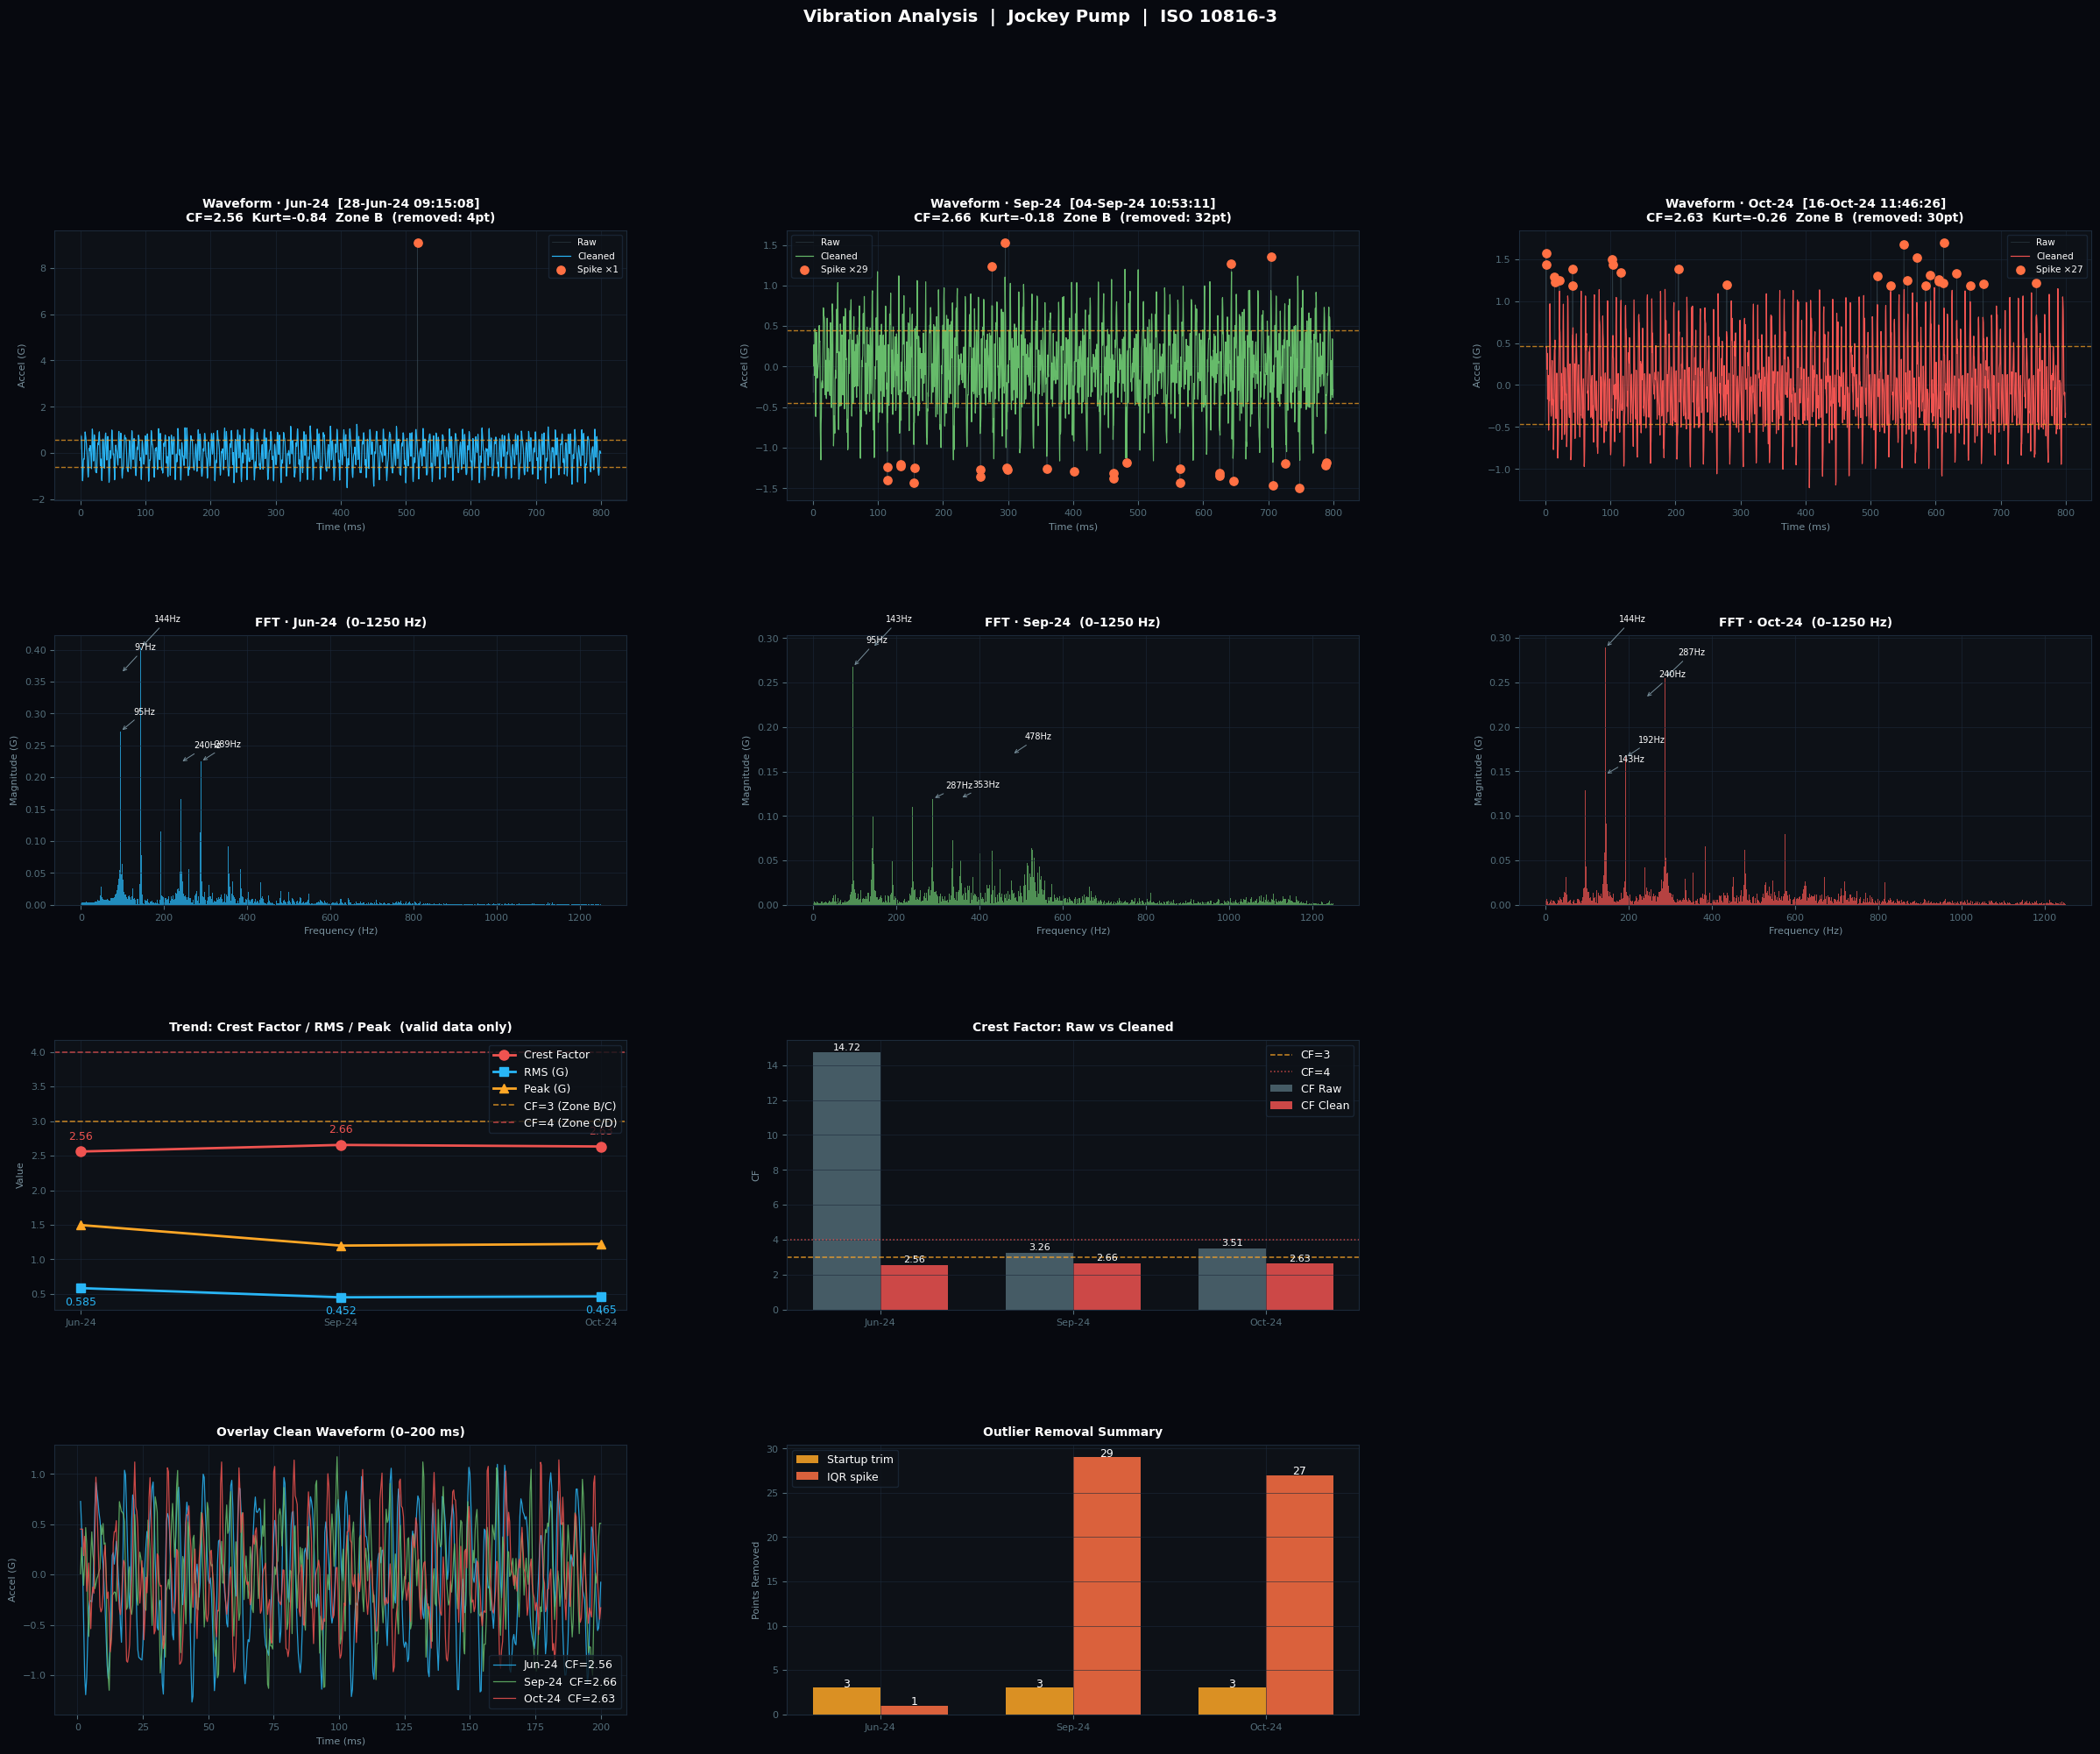

💾 บันทึก: output\vibration_analysis.png


In [13]:
plt.style.use('dark_background')
n_v    = len(ds_valid)
n_cols = max(n_v, 2)
fig = plt.figure(figsize=(10*n_cols, 22))
fig.patch.set_facecolor('#07090f')
gs  = gridspec.GridSpec(4, n_cols, figure=fig, hspace=0.50, wspace=0.28)

# ── Row 0: Waveforms ─────────────────────────────────────────
for col, (ds, color) in enumerate(zip(ds_valid, COLORS_VALID)):
    ax = fig.add_subplot(gs[0, col])
    ax.plot(ds['time_raw'], ds['accel_raw'], color='#455a64', lw=0.5, alpha=0.55, label='Raw')
    ax.plot(ds['time'], ds['accel'], color=color, lw=0.85, label='Cleaned')
    rpt = ds['outlier']
    if rpt['spike_count'] > 0:
        ax.scatter(rpt['spike_times_ms'], rpt['spike_values_g'],
                   color='#ff7043', s=45, zorder=5, label=f"Spike ×{rpt['spike_count']}")
    m = ds['metrics']
    ax.axhline( m['rms'], color='#ffa726', lw=1, ls='--', alpha=0.7)
    ax.axhline(-m['rms'], color='#ffa726', lw=1, ls='--', alpha=0.7)
    style_ax(ax,
             f"Waveform · {ds['label']}  [{ds['meta'].get('datetime','')}]\n"
             f"CF={m['crest']:.2f}  Kurt={m['kurt']:.2f}  Zone {ds['iso_zone']}  "
             f"(removed: {rpt['spike_count']+rpt['trimmed_count']}pt)",
             'Time (ms)', 'Accel (G)')
    ax.legend(fontsize=7.5, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

# ── Row 1: FFT ───────────────────────────────────────────────
for col, (ds, color) in enumerate(zip(ds_valid, COLORS_VALID)):
    ax   = fig.add_subplot(gs[1, col])
    freq = ds['fft_freq']; fmag = ds['fft_mag']
    fmax = min(ds['metrics']['fs']/2, 2000)
    mask = freq <= fmax
    bw   = freq[1]-freq[0] if len(freq)>1 else 1.
    ax.bar(freq[mask], fmag[mask], width=bw, color=color, alpha=0.75, linewidth=0)
    for f0, m0 in ds['top_freqs'][:5]:
        if f0 <= fmax:
            ax.annotate(f'{f0:.0f}Hz', xy=(f0,m0),
                        xytext=(f0+fmax*0.025, m0*1.1), color='white', fontsize=7,
                        arrowprops=dict(arrowstyle='->', color='#78909c', lw=0.7))
    style_ax(ax, f"FFT · {ds['label']}  (0–{fmax:.0f} Hz)", 'Frequency (Hz)', 'Magnitude (G)')

# ── Row 2 col 0: Trend Lines ─────────────────────────────────
ax_trend = fig.add_subplot(gs[2, 0])
x_t      = np.arange(n_v)
cf_vals  = [d['metrics']['crest'] for d in ds_valid]
rms_vals = [d['metrics']['rms']   for d in ds_valid]
pk_vals  = [d['metrics']['peak']  for d in ds_valid]
ax_trend.plot(x_t, cf_vals,  'o-', color='#ef5350', lw=2, ms=8, label='Crest Factor')
ax_trend.plot(x_t, rms_vals, 's-', color='#29b6f6', lw=2, ms=7, label='RMS (G)')
ax_trend.plot(x_t, pk_vals,  '^-', color='#ffa726', lw=2, ms=7, label='Peak (G)')
for xi, cf, rms in zip(x_t, cf_vals, rms_vals):
    ax_trend.annotate(f'{cf:.2f}',  (xi,cf),  textcoords='offset points', xytext=(0,10),  ha='center', color='#ef5350', fontsize=9)
    ax_trend.annotate(f'{rms:.3f}', (xi,rms), textcoords='offset points', xytext=(0,-14), ha='center', color='#29b6f6', fontsize=9)
ax_trend.axhline(3.0, color='#ffa726', lw=1.2, ls='--', alpha=0.7, label='CF=3 (Zone B/C)')
ax_trend.axhline(4.0, color='#ef5350', lw=1.2, ls='--', alpha=0.7, label='CF=4 (Zone C/D)')
ax_trend.set_xticks(x_t); ax_trend.set_xticklabels(labels_valid, color='#cdd9e5', fontsize=10)
style_ax(ax_trend, 'Trend: Crest Factor / RMS / Peak  (valid data only)', '', 'Value')
ax_trend.legend(fontsize=9, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

# ── Row 2 col 1: CF Raw vs Clean ─────────────────────────────
ax_ba = fig.add_subplot(gs[2, 1])
x_ba  = np.arange(n_v); w = 0.35
raw_cf = [d['metrics_raw']['crest'] for d in ds_valid]
cln_cf = [d['metrics']['crest']     for d in ds_valid]
b1 = ax_ba.bar(x_ba-w/2, raw_cf, w, label='CF Raw',   color='#546e7a', alpha=0.8)
b2 = ax_ba.bar(x_ba+w/2, cln_cf, w, label='CF Clean', color='#ef5350', alpha=0.85)
for b in list(b1)+list(b2):
    h = b.get_height()
    if h < 30:
        ax_ba.text(b.get_x()+b.get_width()/2, h+0.05, f'{h:.2f}',
                   ha='center', va='bottom', color='white', fontsize=8)
ax_ba.axhline(3.0, color='#ffa726', lw=1.1, ls='--', alpha=0.8, label='CF=3')
ax_ba.axhline(4.0, color='#ef5350', lw=1.1, ls=':',  alpha=0.8, label='CF=4')
ax_ba.set_xticks(x_ba); ax_ba.set_xticklabels(labels_valid, color='#cdd9e5', fontsize=9)
style_ax(ax_ba, 'Crest Factor: Raw vs Cleaned', '', 'CF')
ax_ba.legend(fontsize=9, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

# ── Row 3 col 0: Overlay ─────────────────────────────────────
ax_ov = fig.add_subplot(gs[3, 0])
for ds, color in zip(ds_valid, COLORS_VALID):
    mask = ds['time'] <= 200
    ax_ov.plot(ds['time'][mask], ds['accel'][mask], color=color, lw=0.9, alpha=0.85,
               label=f"{ds['label']}  CF={ds['metrics']['crest']:.2f}")
style_ax(ax_ov, 'Overlay Clean Waveform (0–200 ms)', 'Time (ms)', 'Accel (G)')
ax_ov.legend(fontsize=9, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

# ── Row 3 col 1: Outlier Summary ─────────────────────────────
ax_sp = fig.add_subplot(gs[3, 1])
n_trim  = [d['outlier']['trimmed_count'] for d in ds_valid]
n_spike = [d['outlier']['spike_count']   for d in ds_valid]
ax_sp.bar(x_ba-w/2, n_trim,  w, label='Startup trim', color='#ffa726', alpha=0.85)
ax_sp.bar(x_ba+w/2, n_spike, w, label='IQR spike',    color='#ff7043', alpha=0.85)
for xi, yt, ys in zip(x_ba, n_trim, n_spike):
    if yt: ax_sp.text(xi-w/2, yt+.05, str(yt), ha='center', color='white', fontsize=9)
    if ys: ax_sp.text(xi+w/2, ys+.05, str(ys), ha='center', color='white', fontsize=9)
ax_sp.set_xticks(x_ba); ax_sp.set_xticklabels(labels_valid, color='#cdd9e5')
style_ax(ax_sp, 'Outlier Removal Summary', '', 'Points Removed')
ax_sp.legend(fontsize=9, facecolor='#0d1117', edgecolor='#1c2a3a', labelcolor='white')

fig.suptitle(
    f"Vibration Analysis  |  {ds_valid[0]['meta'].get('equipment','—')}  |  ISO 10816-3",
    color='white', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
PLOT_FILE = os.path.join(OUTPUT_DIR, 'vibration_analysis.png')
plt.savefig(PLOT_FILE, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
display(fig); plt.close(fig)
print(f"💾 บันทึก: {PLOT_FILE}")


---
## Session 7 — Diagnostic Summary & Trend
> แสดงสภาพเครื่องปัจจุบัน, flag เตือน, และ linear slope (ทิศทางแนวโน้มเท่านั้น)
> ไม่ใช้ ML — ใช้ rule-based และ linear regression สำหรับดู slope


  📋  DIAGNOSTIC SUMMARY & TREND FORECAST  (Degree 2)

  ① สภาพแต่ละ Period
  Period     Zone        CF    RMS(G)   Peak(G)     Kurt  Flag
  ────────────────────────────────────────────────────────────────────────
  Jun-24     Zone B   2.560    0.5847    1.4970   -0.842  ✅ Normal
  Sep-24     Zone B   2.656    0.4518    1.2000   -0.184  ✅ Normal
  Oct-24     Zone B   2.633    0.4648    1.2240   -0.262  ✅ Normal

  ② Trend Analysis (Quadratic Regression — Next Period Prediction)
    Metric               Jun-24      Sep-24      Oct-24      Next (pred)   Trend
    ─────────────────────────────────────────────────────────────────
    RMS (G)              0.5847      0.4518      0.4648      0.6236        ↑
    Peak (G)             1.4970      1.2000      1.2240      1.5690        ↑
    Crest Factor         2.5604      2.6559      2.6334      2.4929        ↓
    Kurtosis             -0.8419     -0.1840     -0.2618     -1.0752       ↓

  ③ Dominant Frequencies (Top 3 per period)
  Rank    Jun-

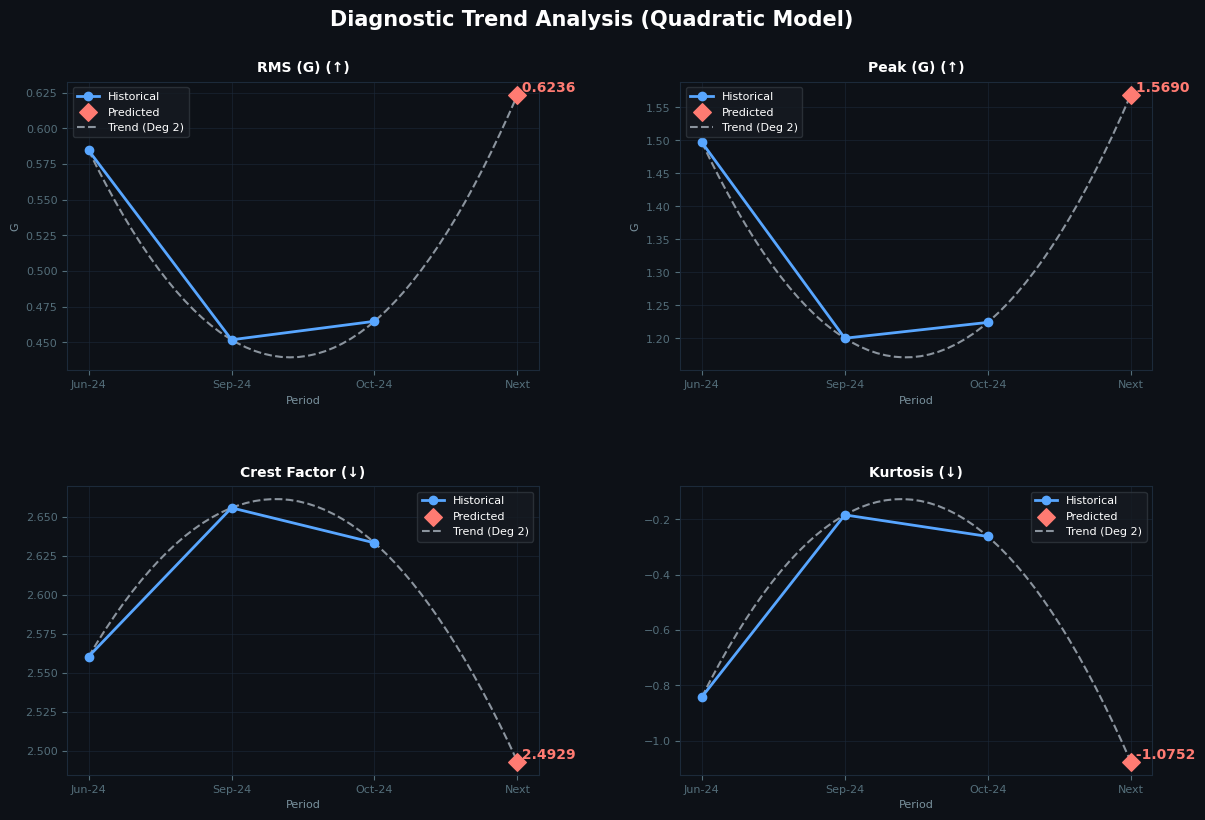


✅ Session 7 Completed (Merged Logic)


In [14]:
# ======================================================================
# ## Session 7 — Diagnostic Summary & Trend (Merged)
# ═══════════════════════════════════════════════════════════════
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("  📋  DIAGNOSTIC SUMMARY & TREND FORECAST  (Degree 2)")
print("=" * 70)

# ── ① สภาพแต่ละ period ────────────────────────────────────────
print("\n  ① สภาพแต่ละ Period")
print(f"  {'Period':<10} {'Zone':<6} {'CF':>7} {'RMS(G)':>9} {'Peak(G)':>9} {'Kurt':>8}  Flag")
print("  " + "─"*72)
for ds in ds_valid:
    m  = ds['metrics']
    z  = ds['iso_zone']
    cf = m['crest']
    flags = []
    if cf > 4.0:   flags.append("🔴 CF>4 Zone D")
    elif cf > 3.0: flags.append("🟡 CF>3 Zone C")
    if m['kurt'] > 3.0: flags.append("⚠ Kurt>3 impulsive")
    if abs(m['skew']) > 1.0: flags.append(f"⚠ Skew={m['skew']:.2f}")
    flag_str = ' | '.join(flags) if flags else '✅ Normal'
    print(f"  {ds['label']:<10} {('Zone '+z):<6} {cf:>7.3f} {m['rms']:>9.4f} {m['peak']:>9.4f} {m['kurt']:>8.3f}  {flag_str}")

# ── ② Trend Analysis (Quadratic Forecast) ──────────────────────
print("\n  ② Trend Analysis (Quadratic Regression — Next Period Prediction)")
if len(ds_valid) < 2:
    print("    ⚠ ต้องการอย่างน้อย 2 period สำหรับ trend analysis")
else:
    n_periods = len(ds_valid)
    plot_labels = [ds['label'] for ds in ds_valid]
    x = np.arange(n_periods, dtype=float).reshape(-1, 1)
    x_next = np.array([[n_periods]])
    
    # Quadratic Degree 2 fallback
    poly_degree = min(2, n_periods - 1)
    poly = PolynomialFeatures(degree=poly_degree)
    x_poly = poly.fit_transform(x)
    x_next_poly = poly.transform(x_next)

    forecast_results = {}
    print(f"    {'Metric':<18} ", end="")
    for lbl in plot_labels:
        print(f"  {lbl:<10}", end="")
    print(f"  {'Next (pred)':<12}  Trend")
    print("    " + "─" * 65)

    metrics_list = [
        ('rms',   'RMS (G)',          'G'),
        ('peak',  'Peak (G)',         'G'),
        ('crest', 'Crest Factor',     ''),
        ('kurt',  'Kurtosis',         '')
    ]

    for metric, label_str, unit in metrics_list:
        y = np.array([ds['metrics'][metric] for ds in ds_valid])
        reg = LinearRegression().fit(x_poly, y)
        y_next = float(reg.predict(x_next_poly)[0])
        y_last = y[-1]
        delta = y_next - y_last
        arrow = "↑" if delta > 0.001 else ("↓" if delta < -0.001 else "→")

        print(f"    {label_str:<18} ", end="")
        for v in y:
            print(f"  {v:<10.4f}", end="")
        print(f"  {y_next:<12.4f}  {arrow}")

        forecast_results[metric] = {
            'values': y.tolist(),
            'predicted': y_next,
            'poly': poly,
            'reg': reg,
            'degree': poly_degree,
            'arrow': arrow,
            'unit': unit,
            'title': label_str
        }

# ── ③ Dominant Frequencies ───────────────────────────────────
print("\n  ③ Dominant Frequencies (Top 3 per period)")
print(f"  {'Rank':<6}", end='')
for ds in ds_valid: print(f"  {ds['label']:<20}", end='')
print("\n  " + "─"*70)
for rank in range(3):
    print(f"  #{rank+1:<5}", end='')
    for ds in ds_valid:
        tf = ds['top_freqs']
        if rank < len(tf):
            print(f"  {tf[rank][0]:.0f} Hz ({tf[rank][1]:.4f}G)  ", end='')
        else:
            print(f"  {'—':<20}", end='')
    print()

# ── ④ Recommendation ─────────────────────────────────────────
last_ds = ds_valid[-1]; last_m = last_ds['metrics']
cf_last = last_m['crest']
cf_pred = forecast_results['crest']['predicted']
print("\n  ④ Recommendation (based on latest & forecast data)")
print(f"     Latest  : {last_ds['label']} | Zone: {last_ds['iso_zone']} | CF: {cf_last:.3f}")
print(f"     Forecast: Next Period | Predicted CF: {cf_pred:.3f}")

if cf_pred > 4.0 or cf_last > 4.0:
    action, interval = "🔴 URGENT — วางแผนเปลี่ยน Bearing ทันที", "ตรวจสอบทุกสัปดาห์"
elif cf_pred > 3.0 or cf_last > 3.0:
    action, interval = "🟡 CAUTION — ตรวจสอบ Bearing, วางแผน PM", "ตรวจสอบทุกเดือน"
else:
    action, interval = "✅ NORMAL — ดำเนินการ PM ตามปกติ", "ตรวจสอบทุกไตรมาส"

print(f"     Action  : {action}\n     Interval: {interval}")

# ── 📊 Visualizing Trend Forecast ────────────────────────────
if len(ds_valid) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=100)
    fig.patch.set_facecolor('#0d1117')
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    x_trend_fine = np.linspace(0, n_periods, 50).reshape(-1, 1)

    for i, (metric_key, _, _) in enumerate(metrics_list):
        ax = axes[i // 2, i % 2]
        res = forecast_results[metric_key]
        
        # Plot historical
        ax.plot(np.arange(n_periods), res['values'], marker='o', color='#58a6ff', lw=2, label='Historical', zorder=3)
        # Plot forecast
        ax.scatter(n_periods, res['predicted'], color='#ff7b72', marker='D', s=80, label='Predicted', zorder=5)
        # Plot trend curve
        y_trend = res['reg'].predict(res['poly'].transform(x_trend_fine))
        ax.plot(x_trend_fine, y_trend, color='#8b949e', ls='--', lw=1.5, label=f"Trend (Deg {res['degree']})", zorder=2)

        style_ax(ax, f"{res['title']} ({res['arrow']})", xlabel='Period', ylabel=res['unit'])
        ax.set_xticks(range(n_periods + 1))
        ax.set_xticklabels(plot_labels + ['Next'])
        ax.legend(fontsize=8, facecolor='#161b22', edgecolor='#30363d', labelcolor='white')
        ax.text(n_periods, res['predicted'], f" {res['predicted']:.4f}", color='#ff7b72', fontweight='bold', va='bottom')

    plt.suptitle(f"Diagnostic Trend Analysis (Quadratic Model)", color='white', fontsize=15, fontweight='bold', y=.96)
    plt.show()

print("\n✅ Session 7 Completed (Merged Logic)")


# Session 7a — RMS / CF / Kurtosis Trend Forecast
ใช้ Linear Regression ทำนายค่าของ period ถัดไป

  📈  TREND FORECAST & VISUALIZATION (Degree 1)

  Metric               Jun-24      Sep-24      Oct-24      Next (pred)   Δ vs last     Trend
  ──────────────────────────────────────────────────────────────────────────────
  RMS (G)              0.5847      0.4518      0.4648      0.3806        -0.0842 (-18.1%)  ↓
  Peak (G)             1.4970      1.2000      1.2240      1.0340        -0.1900 (-15.5%)  ↓
  Crest Factor         2.5604      2.6559      2.6334      2.6895        +0.0562 (+2.1%)  ↑
  Kurtosis             -0.8419     -0.1840     -0.2618     0.1509        +0.4127 (+157.6%)  ↑

  ── Interpretation ──────────────────────────────────
  RMS คาดว่าจะ ↓ → 0.3806 G (Degree=1)
  CF  คาดว่าจะ ↑  → 2.6895 (Degree=1)
  ✅ CF คาดว่าอยู่ในเกณฑ์ปกติ (Zone A/B)


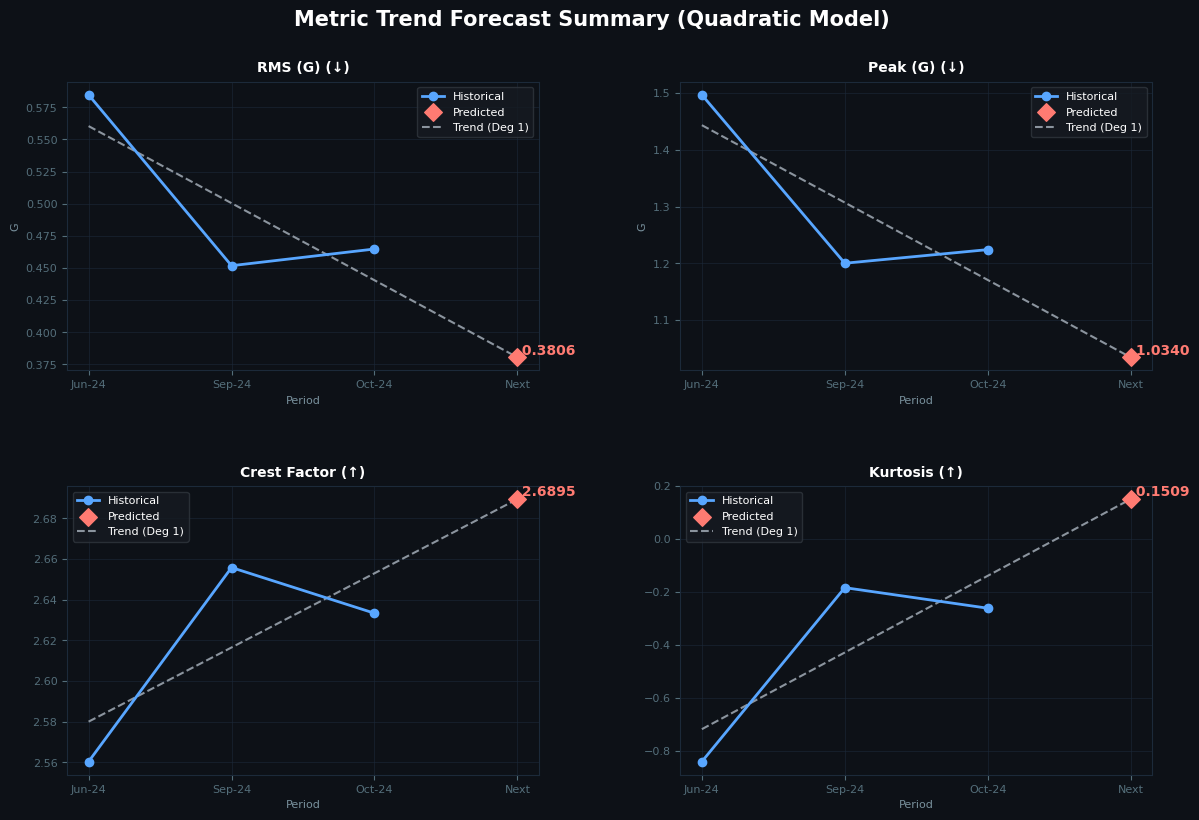


✅ Session 7a Completed (with Graphs)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Session 7a — RMS / CF / Kurtosis Trend Forecast with Graphs
# Use Polynomial Regression (Degree 2) with 2x2 Trend Visualization
# ══════════════════════════════════════════════════════════════
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("  📈  TREND FORECAST & VISUALIZATION (Degree 1)")
print("=" * 70)

if len(ds_valid) < 2:
    print("    ⚠ ต้องการอย่างน้อย 2 period สำหรับ trend analysis และ plotting")
else:
    n_periods = len(ds_valid)
    labels = [ds['label'] for ds in ds_valid]
    x = np.arange(n_periods, dtype=float).reshape(-1, 1)
    x_next = np.array([[n_periods]])
    
    # Quadratic Degree 1 fallback
    poly_degree = min(1, n_periods - 1)
    poly = PolynomialFeatures(degree=poly_degree)
    x_poly = poly.fit_transform(x)
    x_next_poly = poly.transform(x_next)

    # ── 1. Calculate & Print Forecast Table ────────────────────────
    forecast_results = {}
    metrics_list = [
        ('rms',   'RMS (G)',          'G'),
        ('peak',  'Peak (G)',         'G'),
        ('crest', 'Crest Factor',     ''),
        ('kurt',  'Kurtosis',         '')
    ]

    print(f"\n  {'Metric':<18} ", end="")
    for lbl in labels:
        print(f"  {lbl:<10}", end="")
    print(f"  {'Next (pred)':<12}  {'Δ vs last':<12}  Trend")
    print("  " + "─" * 78)

    for metric, label_str, unit in metrics_list:
        y = np.array([ds['metrics'][metric] for ds in ds_valid])
        reg = LinearRegression().fit(x_poly, y)
        y_next = float(reg.predict(x_next_poly)[0])
        y_last = y[-1]
        
        delta = y_next - y_last
        delta_pct = delta / abs(y_last) * 100 if y_last != 0 else 0
        arrow  = "↑" if delta > 0.001 else ("↓" if delta < -0.001 else "→")

        # print row
        print(f"  {label_str:<18} ", end="")
        for v in y:
            print(f"  {v:<10.4f}", end="")
        print(f"  {y_next:<12.4f}  {delta:+.4f} ({delta_pct:+.1f}%)  {arrow}")

        # store for plot and next sessions
        forecast_results[metric] = {
            'values':    y.tolist(),
            'predicted': y_next,
            'delta':     delta,
            'delta_pct': delta_pct,
            'arrow':     arrow,
            'poly':      poly,
            'reg':       reg,
            'degree':    poly_degree,
            'unit':      unit,
            'title':     label_str
        }

    # ── 2. Interpretation Text ────────────────────────────────────
    print("\n  ── Interpretation ──────────────────────────────────")
    rms_f = forecast_results['rms']
    cf_f  = forecast_results['crest']
    print(f"  RMS คาดว่าจะ {rms_f['arrow']} → {rms_f['predicted']:.4f} G (Degree={rms_f['degree']})")
    print(f"  CF  คาดว่าจะ {cf_f['arrow']}  → {cf_f['predicted']:.4f} (Degree={cf_f['degree']})")

    if cf_f['predicted'] > 4.0:
        print("  🔴 CF คาดว่าเกิน 4.0 → ความเสี่ยงสูง Zone D")
    elif cf_f['predicted'] > 3.0:
        print("  🟡 CF คาดว่าอยู่ระหว่าง 3–4 → Zone C (Restricted)")
    else:
        print("  ✅ CF คาดว่าอยู่ในเกณฑ์ปกติ (Zone A/B)")

    # ── 3. Visualizing Trend Forecast (2x2 Grid) ─────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=100)
    fig.patch.set_facecolor('#0d1117')
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    x_trend_fine = np.linspace(0, n_periods, 50).reshape(-1, 1)

    for i, (metric_key, _, _) in enumerate(metrics_list):
        ax = axes[i // 2, i % 2]
        res = forecast_results[metric_key]
        
        # Plot historical
        ax.plot(np.arange(n_periods), res['values'], marker='o', color='#58a6ff', lw=2, label='Historical', zorder=3)
        # Plot forecast
        ax.scatter(n_periods, res['predicted'], color='#ff7b72', marker='D', s=80, label='Predicted', zorder=5)
        # Plot trend curve
        y_trend = res['reg'].predict(res['poly'].transform(x_trend_fine))
        ax.plot(x_trend_fine, y_trend, color='#8b949e', ls='--', lw=1.5, label=f"Trend (Deg {res['degree']})", zorder=2)

        style_ax(ax, f"{res['title']} ({res['arrow']})", xlabel='Period', ylabel=res['unit'])
        ax.set_xticks(range(n_periods + 1))
        ax.set_xticklabels(labels + ['Next'])
        ax.legend(fontsize=8, facecolor='#161b22', edgecolor='#30363d', labelcolor='white')
        
        # Annotate prediction
        ax.text(n_periods, res['predicted'], f" {res['predicted']:.4f}", color='#ff7b72', fontweight='bold', va='bottom')

    plt.suptitle(f"Metric Trend Forecast Summary (Quadratic Model)", color='white', fontsize=15, fontweight='bold', y=.96)
    plt.show()

    print("\n✅ Session 7a Completed (with Graphs)")


---
## Session 8 — Build DataFrames & Export CSV

In [16]:
# ═══════════════════════════════════════════════════════════════
# Session 8 — Build DataFrames, Forecast Summary & Export CSV (FIXED)
# ═══════════════════════════════════════════════════════════════

def dpct(v2, v1):
    return round((v2-v1)/abs(v1)*100, 2) if v1 != 0 else None

# ── 1. Validation results ──────────────────────────────────────
# (df_validation สร้างแล้วใน Session 4)

# ── 2. Metrics per period (valid only) ────────────────────────
metric_rows = []
for ds in ds_valid:
    m=ds['metrics']; mr=ds['metrics_raw']; rpt=ds['outlier']
    metric_rows.append({
        'Period':ds['label'],'Date/Time':ds['meta'].get('datetime','-'),
        'Equipment':ds['meta'].get('equipment','-'),
        'Meas. Point':ds['meta'].get('meas_point','-'),
        'N Raw':mr['n'],'Startup Trimmed':rpt['trimmed_count'],
        'Spikes Removed':rpt['spike_count'],'N Clean':m['n'],
        'Fence Low (G)':rpt.get('fence_lo','-'),'Fence High (G)':rpt.get('fence_hi','-'),
        'RMS raw (G)':round(mr['rms'],5),'RMS clean (G)':round(m['rms'],5),
        'Peak raw (G)':round(mr['peak'],5),'Peak clean (G)':round(m['peak'],5),
        'Peak-to-Peak (G)':round(m['p2p'],5),'Std Dev (G)':round(m['std'],5),
        'CF raw':round(mr['crest'],4),'CF clean':round(m['crest'],4),
        'Kurtosis raw':round(mr['kurt'],4),'Kurtosis clean':round(m['kurt'],4),
        'Skewness':round(m['skew'],4),'Fs (Hz)':round(m['fs'],2),
        'dt (ms)':round(m['dt'],4),'Duration (ms)':round(m['dur'],3),
        'ISO Zone':ds['iso_zone'],'Zone Description':ds['iso_info']['label'],
    })
df_metrics = pd.DataFrame(metric_rows)

# ── 3. Trend table ─────────────────────────────────────────────
trend_rows = []
for mk, lbl in [('rms','RMS (G)'),('peak','Peak (G)'),('p2p','P2P (G)'),
                ('std','Std Dev (G)'),('crest','Crest Factor'),
                ('kurt','Kurtosis'),('skew','Skewness')]:
    row = {'Parameter': lbl}; vals = []
    for ds in ds_valid:
        v = ds['metrics'][mk]; row[ds['label']] = round(v,4); vals.append(v)
    if len(vals) >= 2:
        row['Delta (first→last)']   = round(vals[-1]-vals[0],5)
        row['Delta % (first→last)'] = dpct(vals[-1],vals[0])
    flag = ''
    if mk == 'crest':
        cf_last = ds_valid[-1]['metrics']['crest']
        if cf_last > 4.0:   flag = '🔴 CF>4'
        elif cf_last > 3.0: flag = '🟡 CF>3'
        if row.get('Delta % (first→last)') and abs(row['Delta % (first→last)'])>20:
            flag += ' | ⚠ Change >20%'
    elif mk == 'kurt' and ds_valid[-1]['metrics']['kurt'] > 3.0:
        flag = '⚠ Impulsive'
    row['Flag'] = flag
    trend_rows.append(row)
df_trend = pd.DataFrame(trend_rows)

# ── 4. Top Frequencies ─────────────────────────────────────────
all_top = [ds['top_freqs'] for ds in ds_valid]
n_f = max(len(t) for t in all_top)
freq_dict = {'Rank': list(range(1, n_f+1))}
for ds, tf in zip(ds_valid, all_top):
    lbl = ds['label']
    freq_dict[f'{lbl} Freq (Hz)'] = [round(tf[i][0],2) if i<len(tf) else None for i in range(n_f)]
    freq_dict[f'{lbl} Mag (G)']   = [round(tf[i][1],6) if i<len(tf) else None for i in range(n_f)]
if len(ds_valid) >= 2:
    first_freqs = [f for f,_ in all_top[0]]
    freq_dict['New in last period'] = [
        ('⚠ New' if (f is not None and not any(abs(f-(ff or 0))<=5 for ff in first_freqs)) else '')
        for f in freq_dict[f'{ds_valid[-1]["label"]} Freq (Hz)']
    ]
df_freq = pd.DataFrame(freq_dict)

# ── 5. Outlier detail ──────────────────────────────────────────
out_rows = []
for ds in all_ds:
    rpt = ds['outlier']
    out_rows.append({
        'Period':ds['label'],'Valid':('Yes' if ds['valid'] else 'No'),
        'N Raw':rpt['n_raw'],'Startup Trim':rpt['trimmed_count'],
        'Spikes Removed':rpt['spike_count'],'N Clean':rpt['n_clean'],
        'IQR k':rpt['iqr_k'],'Fence Low':rpt.get('fence_lo','-'),
        'Fence High':rpt.get('fence_hi','-'),
        'Peak Raw (G)':rpt['spike_max_raw'],'Peak After (G)':rpt['peak_after'],
        'Replace Method':rpt['method'],
    })
df_outlier = pd.DataFrame(out_rows)

# ── 6. ★ NEXT PERIOD FORECAST SUMMARY ─────────────
forecast_rows = []
if 'forecast_results' in locals() or 'forecast_results' in globals():
    labels_valid = [ds['label'] for ds in ds_valid]
    for metric, label_str, unit in [
        ('rms',   'RMS (G)',       'G'),
        ('peak',  'Peak (G)',      'G'),
        ('crest', 'Crest Factor',  ''),
        ('kurt',  'Kurtosis',      ''),
    ]:
        if metric not in forecast_results:
            continue
        fr = forecast_results[metric]
        row = {'Parameter': label_str, 'Unit': unit}
        # ใส่ค่าแต่ละ period (historical)
        for lbl, v in zip(labels_valid, fr['values']):
            row[lbl] = round(v, 4)
        row['Next Period (Predicted)'] = fr['predicted']
        row['Δ vs Last Period']        = fr['delta']
        row['Δ% vs Last Period']       = fr['delta_pct']
        row['Trend']                   = fr['arrow']
        # row['Slope (per period)']    = fr.get('slope', '-') # Remove or use get as fallback

        # Risk flag
        risk = ''
        if metric == 'crest':
            if fr['predicted'] > 4.0:  risk = '🔴 Zone D risk'
            elif fr['predicted'] > 3.0: risk = '🟡 Zone C risk'
            else:                        risk = '✅ Zone A/B'
        elif metric == 'rms':
            if fr['delta_pct'] > 20:   risk = '⚠ +20% increase'
            elif fr['delta_pct'] > 10: risk = 'ℹ +10% increase'
        row['Risk Indicator'] = risk
        forecast_rows.append(row)

    df_forecast = pd.DataFrame(forecast_rows)
else:
    print("  ⚠ ไม่พบ forecast_results — กรุณารัน Session 7 ก่อน")
    df_forecast = pd.DataFrame()

# ── Print all sections ─────────────────────────────────────────
sections = [
    ('0. DATA VALIDATION',     df_validation),
    ('1. VIBRATION METRICS',   df_metrics),
    ('2. TREND',               df_trend),
    ('3. TOP FREQUENCIES',     df_freq.fillna('-')),
    ('4. OUTLIER DETAIL',      df_outlier),
]
if not df_forecast.empty:
    sections.append(('5. ★ NEXT PERIOD FORECAST', df_forecast))

for title, df in sections:
    print('\n'+'='*74)
    print(f'  📋 SECTION {title}')
    print('='*74)
    print(df.to_string(index=False))

# ── Forecast highlight box ─────────────────────────────────────
if not df_forecast.empty:
    fr_rms = forecast_results['rms']
    fr_cf  = forecast_results['crest']
    print("\n" + "█"*70)
    print("  🔮  สรุปคาดการณ์ Period ถัดไป")
    print("█"*70)
    print(f"  RMS คาดว่า  : {fr_rms['predicted']:.4f} G  "
          f"({fr_rms['arrow']} {fr_rms['delta_pct']:+.1f}% vs period ล่าสุด)")
    print(f"  CF คาดว่า   : {fr_cf['predicted']:.4f}    "
          f"({fr_cf['arrow']} {fr_cf['delta_pct']:+.1f}% vs period ล่าสุด)")

    # Overall risk recommendation
    cf_pred = fr_cf['predicted']
    if cf_pred > 4.0:
        rec = "🔴 URGENT — CF คาดจะเกิน Zone D → วางแผนหยุดเครื่องตรวจสอบ"
    elif cf_pred > 3.0:
        rec = "🟡 CAUTION — CF คาดจะอยู่ Zone C → เพิ่มความถี่ monitoring"
    else:
        rec = "✅ NORMAL — ค่าทุกตัวคาดว่าอยู่ในเกณฑ์ปกติ"
    print(f"  คำแนะนำ    : {rec}")
    print("█"*70)

# ── Export CSV ─────────────────────────────────────────────────
CSV_FILE = os.path.join(OUTPUT_DIR, 'vibration_full_report.csv')
with open(CSV_FILE, 'w', encoding='utf-8-sig', newline='') as f:
    csv_sections = [
        ('0. DATA VALIDATION',   df_validation),
        ('1. VIBRATION METRICS', df_metrics),
        ('2. TREND',             df_trend),
        ('3. TOP FREQUENCIES',   df_freq.fillna('-')),
        ('4. OUTLIER DETAIL',    df_outlier),
    ]
    if not df_forecast.empty:
        csv_sections.append(('5. NEXT PERIOD FORECAST', df_forecast))
    for hdr, dff in csv_sections:
        f.write(f'=== {hdr} ===\n'); dff.to_csv(f, index=False); f.write('\n')

print(f"\n💾 Exported: {CSV_FILE}")
print("\n✅ Done — ทุก Session เสร็จสมบูรณ์")



  📋 SECTION 0. DATA VALIDATION
Period                              File Valid  Peak raw (G)  CF raw  Kurt raw  Flat ratio  Removed % Reason
Jun-24 A_Jockey pump_M1A_2925__Jun24.txt   Yes         1.497  2.5604   -0.8419      0.0005       0.20       
Sep-24 A_Jockey pump_M1A_2925__Sep24.txt   Yes         1.200  2.6559   -0.1840      0.0010       1.56       
Oct-24 A_Jockey pump_M1A_2925__Oct24.txt   Yes         1.224  2.6334   -0.2618      0.0005       1.47       

  📋 SECTION 1. VIBRATION METRICS
Period          Date/Time   Equipment                               Meas. Point  N Raw  Startup Trimmed  Spikes Removed  N Clean  Fence Low (G)  Fence High (G)  RMS raw (G)  RMS clean (G)  Peak raw (G)  Peak clean (G)  Peak-to-Peak (G)  Std Dev (G)  CF raw  CF clean  Kurtosis raw  Kurtosis clean  Skewness  Fs (Hz)  dt (ms)  Duration (ms) ISO Zone       Zone Description
Jun-24 28-Jun-24 09:15:08 Jockey Pump B-JP-01   -M1A  -->  Motor Outboard Axial   2047                3               1     20